In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew

from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

PATIENT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "02_データ定義・元データ",
    "患者データファイル.csv"
)

SPLIT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "03_患者選定",
    "COVID19_固定患者split_1277.csv"
)

patient_df = pd.read_csv(PATIENT_CSV)
split_df = pd.read_csv(SPLIT_CSV)

clinical_df = patient_df.merge(
    split_df[["Subject ID", "true_label", "split"]],
    left_on="to_patient_id",
    right_on="Subject ID",
    how="inner",
    validate="one_to_one"
)

print("patient_df:", patient_df.shape)
print("split_df:", split_df.shape)
print("clinical_df:", clinical_df.shape)

print("\nSplit counts")
print(clinical_df["split"].value_counts())

Mounted at /content/drive
patient_df: (1384, 131)
split_df: (1277, 5)
clinical_df: (1277, 134)

Split counts
split
train    1021
test      128
val       128
Name: count, dtype: int64


In [4]:
# D-dimer / Troponin / BUN 関連の実際の列名を確認

keywords = ["dimer", "troponin", "urea nitrogen", "bun"]

for kw in keywords:
    print(f"\n=== {kw} ===")
    matches = [
        c for c in clinical_df.columns
        if kw.lower() in c.lower()
    ]
    for c in matches:
        print(c)


=== dimer ===
D_dimer.above3000
D_dimer.between500and3000
D_dimer.below500
48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay

=== troponin ===
Troponin.above0.01
6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma

=== urea nitrogen ===
3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma

=== bun ===


In [5]:
# =========================================
# BUN / Troponin T / D-dimer の分布監査
# =========================================

import numpy as np
import pandas as pd
from scipy.stats import skew

EXTRA_CONTINUOUS_RAW = {
    "bun": "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "troponin": "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "ddimer": "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay"
}

train_mask = clinical_df["split"] == "train"
n_train = train_mask.sum()

rows = []

for short_name, original_col in EXTRA_CONTINUOUS_RAW.items():

    s = pd.to_numeric(
        clinical_df.loc[train_mask, original_col],
        errors="coerce"
    ).dropna()

    rows.append({
        "variable": short_name,
        "n": len(s),
        "missing_n": n_train - len(s),
        "missing_rate": (n_train - len(s)) / n_train,
        "min": s.min(),
        "q1": s.quantile(0.25),
        "median": s.median(),
        "mean": s.mean(),
        "q3": s.quantile(0.75),
        "max": s.max(),
        "n_negative": int((s < 0).sum()),
        "n_zero": int((s == 0).sum()),
        "skew_raw": skew(s, bias=False),
        "skew_log1p": (
            skew(np.log1p(s), bias=False)
            if (s >= 0).all()
            else np.nan
        )
    })

extra_dist = pd.DataFrame(rows)

display(extra_dist)

,variable,n,missing_n,missing_rate,min,q1,median,mean,q3,max,n_negative,n_zero,skew_raw,skew_log1p
0,bun,874,147,0.143976,3.00,10.00,15.00,20.906178,24.00,203.00,0,0,3.558469,0.676196
1,troponin,726,295,0.288932,0.01,0.01,0.01,0.029022,0.01,1.34,0,0,9.510339,7.571835
2,ddimer,711,310,0.303624,150.00,209.00,349.00,1362.676512,655.00,63670.00,0,0,8.314393,1.817365


In [6]:
# =========================================
# Backward AIC再実行前：カテゴリ値の確認
# =========================================

CATEGORICAL_RAW = {
    "age": "age.splits",
    "sex": "gender_concept_name",
    "ckd": "ckd_v",
    "cad": "cad_v",
    "hf": "hf_ef_v"
}

train_df_aic = clinical_df[clinical_df["split"] == "train"].copy()

for short_name, original_col in CATEGORICAL_RAW.items():
    print(f"\n=== {short_name} : {original_col} ===")
    print(train_df_aic[original_col].value_counts(dropna=False))


=== age : age.splits ===
age.splits
[18,59]    544
(59,74]    276
(74,90]    201
Name: count, dtype: int64

=== sex : gender_concept_name ===
gender_concept_name
MALE      562
FEMALE    440
NaN        19
Name: count, dtype: int64

=== ckd : ckd_v ===
ckd_v
No     779
NaN    181
Yes     61
Name: count, dtype: int64

=== cad : cad_v ===
cad_v
No     712
NaN    181
Yes    128
Name: count, dtype: int64

=== hf : hf_ef_v ===
hf_ef_v
No       775
NaN      189
HFpEF     36
HFrEF     21
Name: count, dtype: int64


In [7]:
# =========================================
# 14候補：最終変換ルール込み Backward AIC
# Trainのみ
# =========================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# -----------------------------------------
# 1. 14候補変数
# -----------------------------------------

CONTINUOUS_RAW = {
    "spo2": "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "rr": "9279-1_Respiratory rate",
    "lymph": "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "bun": "3094-0_Urea nitrogen [Mass/volume] in Serum or Plasma",
    "egfr": "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "troponin": "6598-7_Troponin T.cardiac [Mass/volume] in Serum or Plasma",
    "crp": "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "ddimer": "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay",
    "lactate": "2524-7_Lactate [Moles/volume] in Serum or Plasma"
}

CATEGORICAL_RAW = {
    "age": "age.splits",
    "sex": "gender_concept_name",
    "ckd": "ckd_v",
    "cad": "cad_v",
    "hf": "hf_ef_v"
}

LOG1P_VARS = [
    "lymph",
    "bun",
    "crp",
    "ddimer",
    "lactate"
]

# -----------------------------------------
# 2. Trainのみ抽出
# -----------------------------------------

train = clinical_df[
    clinical_df["split"] == "train"
].copy()

y = train["true_label"].astype(int)

# -----------------------------------------
# 3. 連続変数
#    Train中央値補完 → 必要なもののみlog1p
# -----------------------------------------

X_cont = pd.DataFrame(index=train.index)

median_values = {}

for short_name, original_col in CONTINUOUS_RAW.items():

    s = pd.to_numeric(
        train[original_col],
        errors="coerce"
    )

    median = s.median()
    median_values[short_name] = median

    s = s.fillna(median)

    if short_name in LOG1P_VARS:
        s = np.log1p(s)

    X_cont[short_name] = s

# -----------------------------------------
# 4. カテゴリ変数の欠損処理
# -----------------------------------------

X_cat = pd.DataFrame(index=train.index)

# age
X_cat["age"] = pd.Categorical(
    train[CATEGORICAL_RAW["age"]],
    categories=["[18,59]", "(59,74]", "(74,90]"]
)

# sex：Train最頻値で補完
sex_mode = train[CATEGORICAL_RAW["sex"]].mode(dropna=True)[0]

X_cat["sex"] = pd.Categorical(
    train[CATEGORICAL_RAW["sex"]].fillna(sex_mode),
    categories=["FEMALE", "MALE"]
)

# CKD
X_cat["ckd"] = pd.Categorical(
    train[CATEGORICAL_RAW["ckd"]].fillna("Missing"),
    categories=["No", "Yes", "Missing"]
)

# CAD
X_cat["cad"] = pd.Categorical(
    train[CATEGORICAL_RAW["cad"]].fillna("Missing"),
    categories=["No", "Yes", "Missing"]
)

# HF
X_cat["hf"] = pd.Categorical(
    train[CATEGORICAL_RAW["hf"]].fillna("Missing"),
    categories=["No", "HFpEF", "HFrEF", "Missing"]
)

# one-hot
X_cat_dummy = pd.get_dummies(
    X_cat,
    drop_first=True,
    dtype=float
)

# -----------------------------------------
# 5. 全デザイン行列
# -----------------------------------------

X_all = pd.concat(
    [X_cont, X_cat_dummy],
    axis=1
)

print("=== Design matrix ===")
print("shape:", X_all.shape)
print("\ncolumns:")
print(list(X_all.columns))

print("\nmissing:", X_all.isna().sum().sum())

# -----------------------------------------
# 6. 元変数 → ダミー列のグループ対応
# -----------------------------------------

variable_groups = {
    "spo2": ["spo2"],
    "rr": ["rr"],
    "lymph": ["lymph"],
    "bun": ["bun"],
    "egfr": ["egfr"],
    "troponin": ["troponin"],
    "crp": ["crp"],
    "ddimer": ["ddimer"],
    "lactate": ["lactate"],

    "age": [
        "age_(59,74]",
        "age_(74,90]"
    ],

    "sex": [
        "sex_MALE"
    ],

    "ckd": [
        "ckd_Yes",
        "ckd_Missing"
    ],

    "cad": [
        "cad_Yes",
        "cad_Missing"
    ],

    "hf": [
        "hf_HFpEF",
        "hf_HFrEF",
        "hf_Missing"
    ]
}

# -----------------------------------------
# 7. モデルfit関数
# -----------------------------------------

def fit_model(selected_variables):

    cols = []

    for var in selected_variables:
        cols.extend(variable_groups[var])

    X = X_all[cols].copy()
    X = sm.add_constant(X, has_constant="add")

    model = sm.Logit(y, X).fit(
        disp=False,
        maxiter=1000
    )

    return model


# -----------------------------------------
# 8. Backward elimination by AIC
# -----------------------------------------

selected = list(variable_groups.keys())

current_model = fit_model(selected)
current_aic = current_model.aic

history = []

step = 0

print("\n=== Backward AIC start ===")
print(f"Initial variables: {len(selected)}")
print(f"Initial AIC: {current_aic:.6f}")

while True:

    candidates = []

    for var in selected:

        trial_vars = [
            v for v in selected
            if v != var
        ]

        trial_model = fit_model(trial_vars)

        candidates.append({
            "removed_variable": var,
            "aic": trial_model.aic
        })

    candidate_df = pd.DataFrame(candidates)

    best_row = candidate_df.loc[
        candidate_df["aic"].idxmin()
    ]

    best_remove = best_row["removed_variable"]
    best_aic = best_row["aic"]

    # AICが改善した場合のみ削除
    if best_aic < current_aic:

        step += 1

        history.append({
            "step": step,
            "removed_variable": best_remove,
            "aic_before": current_aic,
            "aic_after": best_aic
        })

        selected.remove(best_remove)

        current_model = fit_model(selected)
        current_aic = current_model.aic

        print(
            f"Step {step}: remove {best_remove} "
            f"→ AIC {current_aic:.6f}"
        )

    else:
        break

# -----------------------------------------
# 9. 最終結果
# -----------------------------------------

history_df = pd.DataFrame(history)

print("\n=== Final selected raw variables ===")
print(selected)

print("\nNumber of raw variables:", len(selected))
print("Final AIC:", current_aic)

print("\n=== Removal history ===")
display(history_df)

print("\n=== Final model summary ===")
print(current_model.summary())

=== Design matrix ===
shape: (1021, 19)

columns:
['spo2', 'rr', 'lymph', 'bun', 'egfr', 'troponin', 'crp', 'ddimer', 'lactate', 'age_(59,74]', 'age_(74,90]', 'sex_MALE', 'ckd_Yes', 'ckd_Missing', 'cad_Yes', 'cad_Missing', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

missing: 0

=== Backward AIC start ===
Initial variables: 14
Initial AIC: 522.817471
Step 1: remove troponin → AIC 520.819253
Step 2: remove bun → AIC 518.863145
Step 3: remove cad → AIC 517.083292
Step 4: remove ckd → AIC 516.579347
Step 5: remove rr → AIC 515.765680

=== Final selected raw variables ===
['spo2', 'lymph', 'egfr', 'crp', 'ddimer', 'lactate', 'age', 'sex', 'hf']

Number of raw variables: 9
Final AIC: 515.7656803828733

=== Removal history ===


,step,removed_variable,aic_before,aic_after
0,1,troponin,522.817471,520.819253
1,2,bun,520.819253,518.863145
2,3,cad,518.863145,517.083292
3,4,ckd,517.083292,516.579347
4,5,rr,516.579347,515.765680



=== Final model summary ===
                           Logit Regression Results                           
Dep. Variable:             true_label   No. Observations:                 1021
Model:                          Logit   Df Residuals:                     1008
Method:                           MLE   Df Model:                           12
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.3859
Time:                        03:47:06   Log-Likelihood:                -244.88
converged:                       True   LL-Null:                       -398.79
Covariance Type:            nonrobust   LLR p-value:                 1.068e-58
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.0632      2.131      0.968      0.333      -2.113       6.239
spo2           -0.0848      0.019     -4.520      0.000      -0.122      -0.048
lymph          -2.1

In [8]:
FINAL_RAW_VARIABLES = {
    "age": "age.splits",
    "sex": "gender_concept_name",
    "hf": "hf_ef_v",
    "spo2": "59408-5_Oxygen saturation in Arterial blood by Pulse oximetry",
    "lymph": "731-0_Lymphocytes [#/volume] in Blood by Automated count",
    "egfr": "62238-1_Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)",
    "crp": "1988-5_C reactive protein [Mass/volume] in Serum or Plasma",
    "ddimer": "48058-2_Fibrin D-dimer DDU [Mass/volume] in Platelet poor plasma by Immunoassay",
    "lactate": "2524-7_Lactate [Moles/volume] in Serum or Plasma"
}

model_df = clinical_df[
    ["Subject ID", "true_label", "split"] + list(FINAL_RAW_VARIABLES.values())
].copy()

model_df = model_df.rename(
    columns={v: k for k, v in FINAL_RAW_VARIABLES.items()}
)

train_df = model_df[model_df["split"] == "train"].copy()
val_df = model_df[model_df["split"] == "val"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain deaths:", train_df["true_label"].sum())

Train: (1021, 12)
Val  : (128, 12)
Test : (128, 12)

Train deaths: 135


In [9]:
# =========================================
# 最終6連続変数：
# Train中央値補完 → log1p → 標準化
# =========================================

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

CONTINUOUS_VARS = [
    "spo2",
    "lymph",
    "egfr",
    "crp",
    "ddimer",
    "lactate"
]

LOG1P_VARS = [
    "lymph",
    "crp",
    "ddimer",
    "lactate"
]

NO_LOG_VARS = [
    "spo2",
    "egfr"
]

# -------------------------
# 1. Train中央値で欠損補完
# -------------------------
continuous_imputer = SimpleImputer(strategy="median")

train_cont = pd.DataFrame(
    continuous_imputer.fit_transform(train_df[CONTINUOUS_VARS]),
    columns=CONTINUOUS_VARS,
    index=train_df.index
)

val_cont = pd.DataFrame(
    continuous_imputer.transform(val_df[CONTINUOUS_VARS]),
    columns=CONTINUOUS_VARS,
    index=val_df.index
)

test_cont = pd.DataFrame(
    continuous_imputer.transform(test_df[CONTINUOUS_VARS]),
    columns=CONTINUOUS_VARS,
    index=test_df.index
)

# -------------------------
# 2. log1p変換
# -------------------------
for col in LOG1P_VARS:
    train_cont[col] = np.log1p(train_cont[col])
    val_cont[col] = np.log1p(val_cont[col])
    test_cont[col] = np.log1p(test_cont[col])

# -------------------------
# 3. Train基準で標準化
# -------------------------
continuous_scaler = StandardScaler()

train_cont_scaled = pd.DataFrame(
    continuous_scaler.fit_transform(train_cont),
    columns=CONTINUOUS_VARS,
    index=train_df.index
)

val_cont_scaled = pd.DataFrame(
    continuous_scaler.transform(val_cont),
    columns=CONTINUOUS_VARS,
    index=val_df.index
)

test_cont_scaled = pd.DataFrame(
    continuous_scaler.transform(test_cont),
    columns=CONTINUOUS_VARS,
    index=test_df.index
)

# -------------------------
# 4. 確認
# -------------------------
params = pd.DataFrame({
    "variable": CONTINUOUS_VARS,
    "train_median": continuous_imputer.statistics_,
    "transform": [
        "log1p" if v in LOG1P_VARS else "none"
        for v in CONTINUOUS_VARS
    ],
    "scaler_mean": continuous_scaler.mean_,
    "scaler_scale": continuous_scaler.scale_
})

print("Missing after preprocessing")
print("Train:", train_cont_scaled.isna().sum().sum())
print("Val  :", val_cont_scaled.isna().sum().sum())
print("Test :", test_cont_scaled.isna().sum().sum())

print("\nTrain standardized means")
print(train_cont_scaled.mean())

print("\nPreprocessing parameters")
display(params)

Missing after preprocessing
Train: 0
Val  : 0
Test : 0

Train standardized means
spo2       5.245559e-16
lymph      1.774617e-16
egfr      -1.948599e-16
crp       -3.897198e-16
ddimer     3.062084e-16
lactate   -6.611318e-17
dtype: float64

Preprocessing parameters


,variable,train_median,transform,scaler_mean,scaler_scale
0,spo2,95.00,none,93.787463,5.449517
1,lymph,0.94,log1p,0.684422,0.215322
2,egfr,86.00,none,81.691479,28.708434
3,crp,8.40,log1p,2.142361,0.797838
4,ddimer,349.00,log1p,6.031620,0.894192
5,lactate,1.50,log1p,0.955197,0.292280


In [10]:
# =========================================
# 最終カテゴリ3変数の前処理
# =========================================

from sklearn.preprocessing import OneHotEncoder

CATEGORICAL_VARS = [
    "age",
    "sex",
    "hf"
]

train_cat = train_df[CATEGORICAL_VARS].copy()
val_cat = val_df[CATEGORICAL_VARS].copy()
test_cat = test_df[CATEGORICAL_VARS].copy()

# sex: Train最頻値で補完
sex_mode = train_cat["sex"].mode(dropna=True)[0]

train_cat["sex"] = train_cat["sex"].fillna(sex_mode)
val_cat["sex"] = val_cat["sex"].fillna(sex_mode)
test_cat["sex"] = test_cat["sex"].fillna(sex_mode)

# hf: Missingカテゴリとして保持
train_cat["hf"] = train_cat["hf"].fillna("Missing")
val_cat["hf"] = val_cat["hf"].fillna("Missing")
test_cat["hf"] = test_cat["hf"].fillna("Missing")

# reference categoryを明示
encoder = OneHotEncoder(
    categories=[
        ["[18,59]", "(59,74]", "(74,90]"],
        ["FEMALE", "MALE"],
        ["No", "HFpEF", "HFrEF", "Missing"]
    ],
    drop=[
        "[18,59]",
        "FEMALE",
        "No"
    ],
    handle_unknown="ignore",
    sparse_output=False
)

train_cat_encoded = pd.DataFrame(
    encoder.fit_transform(train_cat),
    columns=encoder.get_feature_names_out(CATEGORICAL_VARS),
    index=train_cat.index
)

val_cat_encoded = pd.DataFrame(
    encoder.transform(val_cat),
    columns=encoder.get_feature_names_out(CATEGORICAL_VARS),
    index=val_cat.index
)

test_cat_encoded = pd.DataFrame(
    encoder.transform(test_cat),
    columns=encoder.get_feature_names_out(CATEGORICAL_VARS),
    index=test_cat.index
)

print("sex mode:", sex_mode)

print("\nEncoded columns:")
print(list(train_cat_encoded.columns))

print("\nShapes")
print("Train:", train_cat_encoded.shape)
print("Val  :", val_cat_encoded.shape)
print("Test :", test_cat_encoded.shape)

sex mode: MALE

Encoded columns:
['age_(59,74]', 'age_(74,90]', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

Shapes
Train: (1021, 6)
Val  : (128, 6)
Test : (128, 6)


In [11]:
# =========================================
# 最終LR入力12列を作成
# =========================================

X_train = pd.concat(
    [train_cont_scaled, train_cat_encoded],
    axis=1
)

X_val = pd.concat(
    [val_cont_scaled, val_cat_encoded],
    axis=1
)

X_test = pd.concat(
    [test_cont_scaled, test_cat_encoded],
    axis=1
)

y_train = train_df["true_label"].copy()
y_val = val_df["true_label"].copy()
y_test = test_df["true_label"].copy()

print("=== Final feature columns ===")
print(list(X_train.columns))

print("\nShapes")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nMissing values")
print("Train:", X_train.isna().sum().sum())
print("Val  :", X_val.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

print("\nOutcome counts")
print("Train deaths:", int(y_train.sum()))
print("Val deaths  :", int(y_val.sum()))
print("Test deaths :", int(y_test.sum()))

=== Final feature columns ===
['spo2', 'lymph', 'egfr', 'crp', 'ddimer', 'lactate', 'age_(59,74]', 'age_(74,90]', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

Shapes
X_train: (1021, 12)
X_val  : (128, 12)
X_test : (128, 12)

Missing values
Train: 0
Val  : 0
Test : 0

Outcome counts
Train deaths: 135
Val deaths  : 17
Test deaths : 17


In [12]:
# =========================================
# 最終12列を作成
# =========================================

X_train = pd.concat(
    [train_cont_scaled, train_cat_encoded],
    axis=1
)

X_val = pd.concat(
    [val_cont_scaled, val_cat_encoded],
    axis=1
)

X_test = pd.concat(
    [test_cont_scaled, test_cat_encoded],
    axis=1
)

y_train = train_df["true_label"].copy()
y_val = val_df["true_label"].copy()
y_test = test_df["true_label"].copy()

print("=== Final feature columns ===")
print(list(X_train.columns))

print("\nShapes")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nMissing values")
print("Train:", X_train.isna().sum().sum())
print("Val  :", X_val.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

print("\nOutcome counts")
print("Train deaths:", int(y_train.sum()))
print("Val deaths  :", int(y_val.sum()))
print("Test deaths :", int(y_test.sum()))

=== Final feature columns ===
['spo2', 'lymph', 'egfr', 'crp', 'ddimer', 'lactate', 'age_(59,74]', 'age_(74,90]', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

Shapes
X_train: (1021, 12)
X_val  : (128, 12)
X_test : (128, 12)

Missing values
Train: 0
Val  : 0
Test : 0

Outcome counts
Train deaths: 135
Val deaths  : 17
Test deaths : 17


In [13]:
# =========================================
# Logistic Regression 8条件比較
# C × class_weight
# =========================================

import numpy as np
import pandas as pd
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.exceptions import ConvergenceWarning

C_VALUES = [0.01, 0.1, 1, 10]
CLASS_WEIGHTS = [None, "balanced"]

results = []
models = {}
val_predictions = {}

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)

    ece = 0.0

    for b in range(n_bins):
        mask = bin_ids == b

        if mask.sum() == 0:
            continue

        mean_prob = y_prob[mask].mean()
        mean_true = y_true[mask].mean()

        ece += (
            mask.sum() / len(y_true)
        ) * abs(mean_prob - mean_true)

    return ece


for C in C_VALUES:
    for class_weight in CLASS_WEIGHTS:

        model = LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            class_weight=class_weight,
            max_iter=5000,
            random_state=42
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)

            model.fit(X_train, y_train)

            convergence_warning = any(
                issubclass(w.category, ConvergenceWarning)
                for w in caught
            )

        val_prob = model.predict_proba(X_val)[:, 1]

        roc_auc = roc_auc_score(
            y_val,
            val_prob
        )

        pr_auc = average_precision_score(
            y_val,
            val_prob
        )

        brier = brier_score_loss(
            y_val,
            val_prob
        )

        ece = expected_calibration_error(
            y_val.to_numpy(),
            val_prob,
            n_bins=10
        )

        condition_name = (
            f"C={C}_class_weight="
            f"{'None' if class_weight is None else class_weight}"
        )

        models[condition_name] = model
        val_predictions[condition_name] = val_prob

        results.append({
            "condition": condition_name,
            "C": C,
            "class_weight": (
                "None"
                if class_weight is None
                else class_weight
            ),
            "val_roc_auc": roc_auc,
            "val_pr_auc": pr_auc,
            "val_brier": brier,
            "val_ece": ece,
            "n_iter": int(model.n_iter_[0]),
            "convergence_warning": convergence_warning
        })


results_df = pd.DataFrame(results)

# 主基準：Validation ROC-AUCの高い順
results_df = results_df.sort_values(
    by=[
        "val_roc_auc",
        "val_pr_auc"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

print("=== Validation comparison ===")
display(results_df)

print("\nBest condition by Validation ROC-AUC:")
display(results_df.iloc[[0]])

=== Validation comparison ===


,condition,C,class_weight,val_roc_auc,val_pr_auc,val_brier,val_ece,n_iter,convergence_warning
0,C=1_class_weight=None,1.00,None,0.896131,0.600921,0.079211,0.075881,7,False
1,C=0.1_class_weight=None,0.10,None,0.894542,0.665454,0.073412,0.045159,5,False
2,C=0.1_class_weight=balanced,0.10,balanced,0.891362,0.625633,0.131298,0.212082,6,False
3,C=10_class_weight=None,10.00,None,0.891362,0.549279,0.083928,0.072648,6,False
4,C=1_class_weight=balanced,1.00,balanced,0.888712,0.568252,0.121585,0.170073,7,False
5,C=0.01_class_weight=None,0.01,None,0.886592,0.694284,0.089242,0.139129,5,False
6,C=0.01_class_weight=balanced,0.01,balanced,0.886063,0.670537,0.164460,0.290734,5,False
7,C=10_class_weight=balanced,10.00,balanced,0.881293,0.504994,0.120541,0.160370,7,False



Best condition by Validation ROC-AUC:


,condition,C,class_weight,val_roc_auc,val_pr_auc,val_brier,val_ece,n_iter,convergence_warning
0,C=1_class_weight=None,1.0,None,0.896131,0.600921,0.079211,0.075881,7,False


In [14]:
# =========================================
# Task B LR 8条件比較結果を保存
# =========================================

import os
import pandas as pd

MODELING_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling"
)

os.makedirs(MODELING_DIR, exist_ok=True)

# 1. 8条件比較表
comparison_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_8条件_Validation比較.csv"
)

results_df.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig"
)

# 2. Validation患者ごとの予測確率
val_pred_df = pd.DataFrame({
    "Subject ID": val_df["Subject ID"].values,
    "true_label": y_val.values
})

for condition_name, probs in val_predictions.items():
    val_pred_df[condition_name] = probs

val_pred_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_8条件_Validation患者別予測確率.csv"
)

val_pred_df.to_csv(
    val_pred_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(comparison_path)
print(val_pred_path)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_8条件_Validation比較.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_8条件_Validation患者別予測確率.csv


In [15]:
# =========================================
# 採用LRモデル + 前処理オブジェクト + 係数を保存
# =========================================

import os
import joblib
import pandas as pd

BEST_CONDITION = "C=1_class_weight=None"
best_model = models[BEST_CONDITION]

# 1. モデル本体
model_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_bestmodel_C1_classweightNone.joblib"
)
joblib.dump(best_model, model_path)

# 2. 前処理オブジェクト
imputer_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_continuous_imputer.joblib"
)
scaler_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_continuous_scaler.joblib"
)
encoder_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_categorical_encoder.joblib"
)

joblib.dump(continuous_imputer, imputer_path)
joblib.dump(continuous_scaler, scaler_path)
joblib.dump(encoder, encoder_path)

# 3. 係数
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_model.coef_[0]
})

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])

coef_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_bestmodel_係数_OR.csv"
)

coef_df.to_csv(
    coef_path,
    index=False,
    encoding="utf-8-sig"
)

# 4. 切片
intercept_df = pd.DataFrame({
    "intercept": best_model.intercept_
})

intercept_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_bestmodel_intercept.csv"
)

intercept_df.to_csv(
    intercept_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(model_path)
print(imputer_path)
print(scaler_path)
print(encoder_path)
print(coef_path)
print(intercept_path)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_bestmodel_C1_classweightNone.joblib
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_continuous_imputer.joblib
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_continuous_scaler.joblib
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_categorical_encoder.joblib
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_bestmodel_係数_OR.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_bestmodel_intercept.csv


In [16]:
# =========================================
# ValidationでYouden index最大の閾値を決定
# =========================================

from sklearn.metrics import roc_curve
import pandas as pd
import numpy as np
import os

best_val_prob = val_predictions["C=1_class_weight=None"]

fpr, tpr, thresholds = roc_curve(
    y_val,
    best_val_prob
)

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)

best_threshold = thresholds[best_idx]
best_sensitivity = tpr[best_idx]
best_specificity = 1 - fpr[best_idx]

print("=== Validation threshold selection ===")
print("Best threshold :", best_threshold)
print("Sensitivity    :", best_sensitivity)
print("Specificity    :", best_specificity)
print("Youden index   :", youden_index[best_idx])

# 保存
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "sensitivity": tpr,
    "specificity": 1 - fpr,
    "youden_index": youden_index
})

threshold_path = os.path.join(
    MODELING_DIR,
    "TaskB_LR_Validation_Youden閾値.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n保存先:")
print(threshold_path)

=== Validation threshold selection ===
Best threshold : 0.12879652675437386
Sensitivity    : 0.9411764705882353
Specificity    : 0.8288288288288288
Youden index   : 0.7700052994170641

保存先:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_LR_Validation_Youden閾値.csv


In [17]:
# =========================================
# Task B Logistic Regression 最終Test評価
# =========================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve
)

# 固定済み最終モデル
BEST_CONDITION = "C=1_class_weight=None"
best_model = models[BEST_CONDITION]

# Validationで固定済みの閾値
FINAL_THRESHOLD = 0.12879652675437386

# -----------------------------------------
# Test予測
# -----------------------------------------

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

# -----------------------------------------
# 指標
# -----------------------------------------

test_roc_auc = roc_auc_score(y_test, test_prob)
test_pr_auc = average_precision_score(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)

test_ece = expected_calibration_error(
    y_test.to_numpy(),
    test_prob,
    n_bins=10
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

test_sensitivity = recall_score(
    y_test,
    test_pred
)

test_specificity = tn / (tn + fp)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

print("=== Task B Logistic Regression Final Test ===")
print(f"ROC-AUC     : {test_roc_auc:.6f}")
print(f"PR-AUC      : {test_pr_auc:.6f}")
print(f"Brier score : {test_brier:.6f}")
print(f"ECE         : {test_ece:.6f}")
print()
print(f"Threshold   : {FINAL_THRESHOLD:.9f}")
print(f"Sensitivity : {test_sensitivity:.6f}")
print(f"Specificity : {test_specificity:.6f}")
print(f"Accuracy    : {test_accuracy:.6f}")
print(f"Precision   : {test_precision:.6f}")
print()
print("Confusion matrix")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

=== Task B Logistic Regression Final Test ===
ROC-AUC     : 0.941176
PR-AUC      : 0.800251
Brier score : 0.057177
ECE         : 0.041302

Threshold   : 0.128796527
Sensitivity : 0.823529
Specificity : 0.810811
Accuracy    : 0.812500
Precision   : 0.400000

Confusion matrix
TN=90, FP=21, FN=3, TP=14


In [18]:
# =========================================
# Task B Test患者別予測を保存
# =========================================

EVAL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

os.makedirs(EVAL_DIR, exist_ok=True)

test_pred_df = pd.DataFrame({
    "Subject ID": test_df["Subject ID"].values,
    "true_label": y_test.values,
    "prob": test_prob,
    "pred": test_pred
})

test_pred_path = os.path.join(
    EVAL_DIR,
    "TaskB_LR_Test患者別予測.csv"
)

test_pred_df.to_csv(
    test_pred_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(test_pred_path)

print("\nShape:", test_pred_df.shape)
print("\n先頭5行")
display(test_pred_df.head())

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_LR_Test患者別予測.csv

Shape: (128, 4)

先頭5行


,Subject ID,true_label,prob,pred
0,A387558,1,0.799579,1
1,A642300,1,0.885586,1
2,A769593,1,0.294029,1
3,A104425,0,0.027194,0
4,A919435,0,0.430578,1


In [19]:
# =========================================
# Task B Test ROC-AUC 95% CI
# stratified bootstrap 10,000回
# =========================================

import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)

y_test_np = np.asarray(y_test)
test_prob_np = np.asarray(test_prob)

pos_idx = np.where(y_test_np == 1)[0]
neg_idx = np.where(y_test_np == 0)[0]

n_boot = 10000
boot_aucs = []

for _ in range(n_boot):
    boot_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )
    boot_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    boot_idx = np.concatenate([
        boot_pos,
        boot_neg
    ])

    auc = roc_auc_score(
        y_test_np[boot_idx],
        test_prob_np[boot_idx]
    )

    boot_aucs.append(auc)

boot_aucs = np.array(boot_aucs)

auc_ci_lower = np.percentile(boot_aucs, 2.5)
auc_ci_upper = np.percentile(boot_aucs, 97.5)

print("=== Task B Test ROC-AUC 95% CI ===")
print(f"ROC-AUC : {test_roc_auc:.6f}")
print(f"95% CI  : {auc_ci_lower:.4f} - {auc_ci_upper:.4f}")
print(f"Bootstrap repetitions: {n_boot}")
print("Random seed: 42")

=== Task B Test ROC-AUC 95% CI ===
ROC-AUC : 0.941176
95% CI  : 0.8877 - 0.9830
Bootstrap repetitions: 10000
Random seed: 42


In [20]:
# =========================================
# Task B Logistic Regression
# 最終Test評価結果を保存
# =========================================

final_metrics_df = pd.DataFrame([{
    "model": "TaskB_LogisticRegression",
    "C": 1.0,
    "class_weight": "None",
    "threshold": FINAL_THRESHOLD,
    "roc_auc": test_roc_auc,
    "roc_auc_ci_lower": auc_ci_lower,
    "roc_auc_ci_upper": auc_ci_upper,
    "pr_auc": test_pr_auc,
    "brier_score": test_brier,
    "ece": test_ece,
    "sensitivity": test_sensitivity,
    "specificity": test_specificity,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "bootstrap_repetitions": 10000,
    "bootstrap_seed": 42
}])

metrics_path = os.path.join(
    EVAL_DIR,
    "TaskB_LR_最終Test評価結果.csv"
)

final_metrics_df.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(metrics_path)

display(final_metrics_df)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_LR_最終Test評価結果.csv


,model,C,class_weight,threshold,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,pr_auc,brier_score,ece,sensitivity,specificity,accuracy,precision,TN,FP,FN,TP,bootstrap_repetitions,bootstrap_seed
0,TaskB_LogisticRegression,1.0,None,0.128797,0.941176,0.887652,0.983042,0.800251,0.057177,0.041302,0.823529,0.810811,0.8125,0.4,90,21,3,14,10000,42


In [22]:
# =========================================
# XGBoost用に特徴量名だけ安全な形式へ変更
# =========================================

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

rename_map = {
    "age_(59,74]": "age_59_74",
    "age_(74,90]": "age_74_90"
}

X_train_xgb = X_train_xgb.rename(columns=rename_map)
X_val_xgb = X_val_xgb.rename(columns=rename_map)

print("Train shape:", X_train_xgb.shape)
print("Val shape  :", X_val_xgb.shape)

print("\nXGBoost feature names:")
print(X_train_xgb.columns.tolist())

Train shape: (1021, 12)
Val shape  : (128, 12)

XGBoost feature names:
['spo2', 'lymph', 'egfr', 'crp', 'ddimer', 'lactate', 'age_59_74', 'age_74_90', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']


In [23]:
# =========================================
# Task B XGBoost Stage 1
# 18条件比較・完全版
# =========================================

import xgboost as xgb
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("XGBoost version:", xgb.__version__)

# -----------------------------------------
# XGBoost用に特徴量名だけ変更
# ※値は一切変更しない
# -----------------------------------------

X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

rename_map = {
    "age_(59,74]": "age_59_74",
    "age_(74,90]": "age_74_90"
}

X_train_xgb = X_train_xgb.rename(columns=rename_map)
X_val_xgb = X_val_xgb.rename(columns=rename_map)

print("\nTrain shape:", X_train_xgb.shape)
print("Val shape  :", X_val_xgb.shape)

print("\nXGBoost feature names:")
print(X_train_xgb.columns.tolist())

# -----------------------------------------
# Stage 1 探索条件
# -----------------------------------------

MAX_DEPTHS = [2, 3, 4]
LEARNING_RATES = [0.03, 0.05, 0.1]
MIN_CHILD_WEIGHTS = [1, 5]

# Stage 1では固定
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8
SCALE_POS_WEIGHT = 1.0
REG_ALPHA = 0
REG_LAMBDA = 1

# -----------------------------------------
# 結果格納用
# -----------------------------------------

stage1_results = []
stage1_models = {}
stage1_val_predictions = {}

# -----------------------------------------
# 18条件比較
# -----------------------------------------

for max_depth in MAX_DEPTHS:
    for learning_rate in LEARNING_RATES:
        for min_child_weight in MIN_CHILD_WEIGHTS:

            condition = (
                f"depth={max_depth}_"
                f"lr={learning_rate}_"
                f"mcw={min_child_weight}"
            )

            model = xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="auc",
                tree_method="hist",

                max_depth=max_depth,
                learning_rate=learning_rate,
                min_child_weight=min_child_weight,

                subsample=SUBSAMPLE,
                colsample_bytree=COLSAMPLE_BYTREE,
                scale_pos_weight=SCALE_POS_WEIGHT,

                reg_alpha=REG_ALPHA,
                reg_lambda=REG_LAMBDA,

                n_estimators=2000,
                early_stopping_rounds=50,

                random_state=42,
                n_jobs=-1
            )

            model.fit(
                X_train_xgb,
                y_train,
                eval_set=[(X_val_xgb, y_val)],
                verbose=False
            )

            # Validation予測確率
            val_prob = model.predict_proba(
                X_val_xgb
            )[:, 1]

            # 評価指標
            val_roc_auc = roc_auc_score(
                y_val,
                val_prob
            )

            val_pr_auc = average_precision_score(
                y_val,
                val_prob
            )

            val_brier = brier_score_loss(
                y_val,
                val_prob
            )

            val_ece = expected_calibration_error(
                y_val.to_numpy(),
                val_prob,
                n_bins=10
            )

            # best_iterationは0始まり
            best_iteration = model.best_iteration
            n_trees = best_iteration + 1

            # 保存
            stage1_models[condition] = model
            stage1_val_predictions[condition] = val_prob

            stage1_results.append({
                "condition": condition,
                "max_depth": max_depth,
                "learning_rate": learning_rate,
                "min_child_weight": min_child_weight,
                "subsample": SUBSAMPLE,
                "colsample_bytree": COLSAMPLE_BYTREE,
                "scale_pos_weight": SCALE_POS_WEIGHT,
                "reg_alpha": REG_ALPHA,
                "reg_lambda": REG_LAMBDA,
                "val_roc_auc": val_roc_auc,
                "val_pr_auc": val_pr_auc,
                "val_brier": val_brier,
                "val_ece": val_ece,
                "best_iteration": best_iteration,
                "n_trees": n_trees
            })

# -----------------------------------------
# 結果一覧
# -----------------------------------------

stage1_results_df = pd.DataFrame(
    stage1_results
).sort_values(
    by=[
        "val_roc_auc",
        "val_pr_auc"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

print("\n=== XGBoost Stage 1: 18条件比較 ===")
display(stage1_results_df)

print("\n=== Validation ROC-AUC最大条件 ===")
display(stage1_results_df.iloc[[0]])

XGBoost version: 3.4.1

Train shape: (1021, 12)
Val shape  : (128, 12)

XGBoost feature names:
['spo2', 'lymph', 'egfr', 'crp', 'ddimer', 'lactate', 'age_59_74', 'age_74_90', 'sex_MALE', 'hf_HFpEF', 'hf_HFrEF', 'hf_Missing']

=== XGBoost Stage 1: 18条件比較 ===


,condition,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,scale_pos_weight,reg_alpha,reg_lambda,val_roc_auc,val_pr_auc,val_brier,val_ece,best_iteration,n_trees
0,depth=3_lr=0.1_mcw=1,3,0.10,1,0.8,0.8,1.0,0,1,0.885533,0.539380,0.085551,0.063749,24,25
1,depth=4_lr=0.1_mcw=1,4,0.10,1,0.8,0.8,1.0,0,1,0.881293,0.560686,0.083818,0.053971,23,24
2,depth=4_lr=0.05_mcw=5,4,0.05,5,0.8,0.8,1.0,0,1,0.877848,0.551399,0.090307,0.059685,25,26
3,depth=4_lr=0.1_mcw=5,4,0.10,5,0.8,0.8,1.0,0,1,0.876789,0.558091,0.086143,0.055195,22,23
4,depth=2_lr=0.1_mcw=1,2,0.10,1,0.8,0.8,1.0,0,1,0.875464,0.534550,0.086129,0.037350,74,75
5,depth=2_lr=0.03_mcw=1,2,0.03,1,0.8,0.8,1.0,0,1,0.875199,0.566966,0.087975,0.055150,78,79
6,depth=2_lr=0.05_mcw=1,2,0.05,1,0.8,0.8,1.0,0,1,0.874934,0.551190,0.084625,0.056049,150,151
7,depth=2_lr=0.1_mcw=5,2,0.10,5,0.8,0.8,1.0,0,1,0.874669,0.595817,0.088359,0.054205,15,16
8,depth=4_lr=0.03_mcw=1,4,0.03,1,0.8,0.8,1.0,0,1,0.874404,0.590812,0.082960,0.074222,108,109
9,depth=4_lr=0.03_mcw=5,4,0.03,5,0.8,0.8,1.0,0,1,0.874404,0.550972,0.094945,0.064624,27,28



=== Validation ROC-AUC最大条件 ===


,condition,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,scale_pos_weight,reg_alpha,reg_lambda,val_roc_auc,val_pr_auc,val_brier,val_ece,best_iteration,n_trees
0,depth=3_lr=0.1_mcw=1,3,0.1,1,0.8,0.8,1.0,0,1,0.885533,0.53938,0.085551,0.063749,24,25


In [24]:
# =========================================
# XGBoost Stage 1 結果保存
# =========================================

import os
import pandas as pd

MODELING_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling"
)

os.makedirs(MODELING_DIR, exist_ok=True)

# 1. 18条件比較表
stage1_result_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_Stage1_18条件比較.csv"
)

stage1_results_df.to_csv(
    stage1_result_path,
    index=False,
    encoding="utf-8-sig"
)

# 2. Validation患者別予測確率
stage1_val_pred_df = pd.DataFrame({
    "Subject ID": val_df["Subject ID"].values,
    "true_label": y_val.values
})

for condition, probs in stage1_val_predictions.items():
    stage1_val_pred_df[condition] = probs

stage1_val_pred_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_Stage1_Validation患者別予測確率.csv"
)

stage1_val_pred_df.to_csv(
    stage1_val_pred_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(stage1_result_path)
print(stage1_val_pred_path)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_Stage1_18条件比較.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_Stage1_Validation患者別予測確率.csv


In [25]:
# =========================================
# Task B XGBoost Stage 2
# 16条件比較
# =========================================

import xgboost as xgb
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# -----------------------------------------
# Stage 1で確定した条件
# -----------------------------------------

FIXED_MAX_DEPTH = 3
FIXED_LEARNING_RATE = 0.1
FIXED_MIN_CHILD_WEIGHT = 1

# -----------------------------------------
# Stage 2 探索条件
# -----------------------------------------

SUBSAMPLES = [0.8, 1.0]
COLSAMPLE_BYTREES = [0.8, 1.0]
SCALE_POS_WEIGHTS = [
    1.0,
    886 / 135
]
REG_ALPHAS = [0, 1]

REG_LAMBDA = 1

print(
    "scale_pos_weight:",
    886 / 135
)

# -----------------------------------------
# 結果格納
# -----------------------------------------

stage2_results = []
stage2_models = {}
stage2_val_predictions = {}

# -----------------------------------------
# 16条件比較
# -----------------------------------------

for subsample in SUBSAMPLES:
    for colsample_bytree in COLSAMPLE_BYTREES:
        for scale_pos_weight in SCALE_POS_WEIGHTS:
            for reg_alpha in REG_ALPHAS:

                condition = (
                    f"sub={subsample}_"
                    f"col={colsample_bytree}_"
                    f"spw={scale_pos_weight:.4f}_"
                    f"alpha={reg_alpha}"
                )

                model = xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="auc",
                    tree_method="hist",

                    max_depth=FIXED_MAX_DEPTH,
                    learning_rate=FIXED_LEARNING_RATE,
                    min_child_weight=FIXED_MIN_CHILD_WEIGHT,

                    subsample=subsample,
                    colsample_bytree=colsample_bytree,
                    scale_pos_weight=scale_pos_weight,

                    reg_alpha=reg_alpha,
                    reg_lambda=REG_LAMBDA,

                    n_estimators=2000,
                    early_stopping_rounds=50,

                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_train_xgb,
                    y_train,
                    eval_set=[
                        (X_val_xgb, y_val)
                    ],
                    verbose=False
                )

                val_prob = model.predict_proba(
                    X_val_xgb
                )[:, 1]

                val_roc_auc = roc_auc_score(
                    y_val,
                    val_prob
                )

                val_pr_auc = average_precision_score(
                    y_val,
                    val_prob
                )

                val_brier = brier_score_loss(
                    y_val,
                    val_prob
                )

                val_ece = expected_calibration_error(
                    y_val.to_numpy(),
                    val_prob,
                    n_bins=10
                )

                best_iteration = model.best_iteration
                n_trees = best_iteration + 1

                stage2_models[condition] = model
                stage2_val_predictions[
                    condition
                ] = val_prob

                stage2_results.append({
                    "condition": condition,
                    "max_depth": FIXED_MAX_DEPTH,
                    "learning_rate":
                        FIXED_LEARNING_RATE,
                    "min_child_weight":
                        FIXED_MIN_CHILD_WEIGHT,
                    "subsample": subsample,
                    "colsample_bytree":
                        colsample_bytree,
                    "scale_pos_weight":
                        scale_pos_weight,
                    "reg_alpha": reg_alpha,
                    "reg_lambda": REG_LAMBDA,
                    "val_roc_auc":
                        val_roc_auc,
                    "val_pr_auc":
                        val_pr_auc,
                    "val_brier":
                        val_brier,
                    "val_ece":
                        val_ece,
                    "best_iteration":
                        best_iteration,
                    "n_trees":
                        n_trees
                })

# -----------------------------------------
# 結果一覧
# -----------------------------------------

stage2_results_df = pd.DataFrame(
    stage2_results
).sort_values(
    by=[
        "val_roc_auc",
        "val_pr_auc"
    ],
    ascending=[
        False,
        False
    ]
).reset_index(drop=True)

print(
    "\n=== XGBoost Stage 2: 16条件比較 ==="
)
display(stage2_results_df)

print(
    "\n=== Validation ROC-AUC最大条件 ==="
)
display(stage2_results_df.iloc[[0]])

scale_pos_weight: 6.562962962962963

=== XGBoost Stage 2: 16条件比較 ===


,condition,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,scale_pos_weight,reg_alpha,reg_lambda,val_roc_auc,val_pr_auc,val_brier,val_ece,best_iteration,n_trees
0,sub=0.8_col=0.8_spw=1.0000_alpha=0,3,0.1,1,0.8,0.8,1.000000,0,1,0.885533,0.539380,0.085551,0.063749,24,25
1,sub=0.8_col=0.8_spw=1.0000_alpha=1,3,0.1,1,0.8,0.8,1.000000,1,1,0.878908,0.595049,0.086102,0.051948,15,16
2,sub=0.8_col=1.0_spw=6.5630_alpha=0,3,0.1,1,0.8,1.0,6.562963,0,1,0.874934,0.528168,0.110175,0.109929,63,64
3,sub=0.8_col=1.0_spw=1.0000_alpha=0,3,0.1,1,0.8,1.0,1.000000,0,1,0.873079,0.598175,0.092415,0.078302,7,8
4,sub=0.8_col=1.0_spw=1.0000_alpha=1,3,0.1,1,0.8,1.0,1.000000,1,1,0.871489,0.620760,0.094202,0.075617,6,7
5,sub=1.0_col=1.0_spw=6.5630_alpha=1,3,0.1,1,1.0,1.0,6.562963,1,1,0.869634,0.509775,0.112985,0.132164,51,52
6,sub=1.0_col=1.0_spw=6.5630_alpha=0,3,0.1,1,1.0,1.0,6.562963,0,1,0.869104,0.516584,0.106107,0.107576,79,80
7,sub=0.8_col=0.8_spw=6.5630_alpha=1,3,0.1,1,0.8,0.8,6.562963,1,1,0.868045,0.530558,0.111983,0.132319,61,62
8,sub=0.8_col=1.0_spw=6.5630_alpha=1,3,0.1,1,0.8,1.0,6.562963,1,1,0.867515,0.504926,0.109385,0.110130,64,65
9,sub=1.0_col=1.0_spw=1.0000_alpha=0,3,0.1,1,1.0,1.0,1.000000,0,1,0.863275,0.548331,0.085991,0.058950,137,138



=== Validation ROC-AUC最大条件 ===


,condition,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,scale_pos_weight,reg_alpha,reg_lambda,val_roc_auc,val_pr_auc,val_brier,val_ece,best_iteration,n_trees
0,sub=0.8_col=0.8_spw=1.0000_alpha=0,3,0.1,1,0.8,0.8,1.0,0,1,0.885533,0.53938,0.085551,0.063749,24,25


In [26]:
# =========================================
# XGBoost Stage 2 結果保存
# =========================================

import os
import pandas as pd

MODELING_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling"
)

os.makedirs(MODELING_DIR, exist_ok=True)

# 1. Stage 2 16条件比較表
stage2_result_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_Stage2_16条件比較.csv"
)

stage2_results_df.to_csv(
    stage2_result_path,
    index=False,
    encoding="utf-8-sig"
)

# 2. Validation患者別予測確率
stage2_val_pred_df = pd.DataFrame({
    "Subject ID": val_df["Subject ID"].values,
    "true_label": y_val.values
})

for condition, probs in stage2_val_predictions.items():
    stage2_val_pred_df[condition] = probs

stage2_val_pred_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_Stage2_Validation患者別予測確率.csv"
)

stage2_val_pred_df.to_csv(
    stage2_val_pred_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(stage2_result_path)
print(stage2_val_pred_path)

print("\nStage 2 comparison shape:", stage2_results_df.shape)
print("Validation prediction shape:", stage2_val_pred_df.shape)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_Stage2_16条件比較.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_Stage2_Validation患者別予測確率.csv

Stage 2 comparison shape: (16, 15)
Validation prediction shape: (128, 18)


In [27]:
# =========================================
# Task B XGBoost best model 保存
# =========================================

import os
import joblib
import pandas as pd

BEST_XGB_CONDITION = (
    "sub=0.8_col=0.8_spw=1.0000_alpha=0"
)

best_xgb_model = stage2_models[BEST_XGB_CONDITION]

# 1. モデル本体
xgb_model_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_bestmodel.joblib"
)

joblib.dump(
    best_xgb_model,
    xgb_model_path
)

# 2. XGBoostネイティブ形式でも保存
xgb_json_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_bestmodel.json"
)

best_xgb_model.save_model(
    xgb_json_path
)

# 3. 特徴量重要度
importance_df = pd.DataFrame({
    "feature": X_train_xgb.columns,
    "importance": best_xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_特徴量重要度.csv"
)

importance_df.to_csv(
    importance_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(xgb_model_path)
print(xgb_json_path)
print(importance_path)

print("\n=== Feature importance ===")
display(importance_df)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_bestmodel.joblib
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_bestmodel.json
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_特徴量重要度.csv

=== Feature importance ===


,feature,importance
0,age_74_90,0.132887
1,lactate,0.123365
2,age_59_74,0.116694
3,egfr,0.115654
4,ddimer,0.080054
5,spo2,0.075920
6,lymph,0.069714
7,crp,0.068163
8,hf_HFpEF,0.067245
9,hf_HFrEF,0.062089


In [28]:
# =========================================
# XGBoost ValidationでYouden閾値を決定
# =========================================

from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd
import os

# best modelのValidation予測
best_xgb_val_prob = best_xgb_model.predict_proba(
    X_val_xgb
)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_val,
    best_xgb_val_prob
)

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)

xgb_best_threshold = thresholds[best_idx]
xgb_val_sensitivity = tpr[best_idx]
xgb_val_specificity = 1 - fpr[best_idx]

print("=== XGBoost Validation threshold selection ===")
print("Best threshold :", xgb_best_threshold)
print("Sensitivity    :", xgb_val_sensitivity)
print("Specificity    :", xgb_val_specificity)
print("Youden index   :", youden_index[best_idx])

# 閾値候補一覧を保存
xgb_threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "sensitivity": tpr,
    "specificity": 1 - fpr,
    "youden_index": youden_index
})

xgb_threshold_path = os.path.join(
    MODELING_DIR,
    "TaskB_XGBoost_Validation_Youden閾値.csv"
)

xgb_threshold_df.to_csv(
    xgb_threshold_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n保存先:")
print(xgb_threshold_path)

=== XGBoost Validation threshold selection ===
Best threshold : 0.13113779
Sensitivity    : 0.8823529411764706
Specificity    : 0.8288288288288288
Youden index   : 0.7111817700052994

保存先:
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_XGBoost_Validation_Youden閾値.csv


In [29]:
# =========================================
# Task B XGBoost 最終Test評価
# =========================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

# -----------------------------------------
# Test用特徴量名をXGBoost用に変更
# -----------------------------------------

X_test_xgb = X_test.copy()

rename_map = {
    "age_(59,74]": "age_59_74",
    "age_(74,90]": "age_74_90"
}

X_test_xgb = X_test_xgb.rename(columns=rename_map)

# -----------------------------------------
# 固定済み閾値
# -----------------------------------------

FINAL_XGB_THRESHOLD = 0.13113779

# -----------------------------------------
# Test予測
# -----------------------------------------

xgb_test_prob = best_xgb_model.predict_proba(
    X_test_xgb
)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= FINAL_XGB_THRESHOLD
).astype(int)

# -----------------------------------------
# 評価指標
# -----------------------------------------

xgb_test_roc_auc = roc_auc_score(
    y_test,
    xgb_test_prob
)

xgb_test_pr_auc = average_precision_score(
    y_test,
    xgb_test_prob
)

xgb_test_brier = brier_score_loss(
    y_test,
    xgb_test_prob
)

xgb_test_ece = expected_calibration_error(
    y_test.to_numpy(),
    xgb_test_prob,
    n_bins=10
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    xgb_test_pred
).ravel()

xgb_test_sensitivity = recall_score(
    y_test,
    xgb_test_pred
)

xgb_test_specificity = tn / (tn + fp)

xgb_test_accuracy = accuracy_score(
    y_test,
    xgb_test_pred
)

xgb_test_precision = precision_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

print("=== Task B XGBoost Final Test ===")
print(f"ROC-AUC     : {xgb_test_roc_auc:.6f}")
print(f"PR-AUC      : {xgb_test_pr_auc:.6f}")
print(f"Brier score : {xgb_test_brier:.6f}")
print(f"ECE         : {xgb_test_ece:.6f}")
print()
print(f"Threshold   : {FINAL_XGB_THRESHOLD:.8f}")
print(f"Sensitivity : {xgb_test_sensitivity:.6f}")
print(f"Specificity : {xgb_test_specificity:.6f}")
print(f"Accuracy    : {xgb_test_accuracy:.6f}")
print(f"Precision   : {xgb_test_precision:.6f}")
print()
print("Confusion matrix")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

=== Task B XGBoost Final Test ===
ROC-AUC     : 0.935877
PR-AUC      : 0.718188
Brier score : 0.067800
ECE         : 0.090264

Threshold   : 0.13113779
Sensitivity : 0.941176
Specificity : 0.783784
Accuracy    : 0.804688
Precision   : 0.400000

Confusion matrix
TN=87, FP=24, FN=1, TP=16


In [30]:
# =========================================
# Task B XGBoost Test患者別予測を保存
# =========================================

EVAL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

os.makedirs(EVAL_DIR, exist_ok=True)

xgb_test_pred_df = pd.DataFrame({
    "Subject ID": test_df["Subject ID"].values,
    "true_label": y_test.values,
    "prob": xgb_test_prob,
    "pred": xgb_test_pred
})

xgb_test_pred_path = os.path.join(
    EVAL_DIR,
    "TaskB_XGBoost_Test患者別予測.csv"
)

xgb_test_pred_df.to_csv(
    xgb_test_pred_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(xgb_test_pred_path)
print("Shape:", xgb_test_pred_df.shape)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_XGBoost_Test患者別予測.csv
Shape: (128, 4)


In [31]:
# =========================================
# Task B XGBoost Test ROC-AUC 95% CI
# stratified bootstrap 10,000回
# =========================================

import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)

y_test_np = np.asarray(y_test)
xgb_test_prob_np = np.asarray(xgb_test_prob)

pos_idx = np.where(y_test_np == 1)[0]
neg_idx = np.where(y_test_np == 0)[0]

n_boot = 10000
boot_aucs = []

for _ in range(n_boot):
    boot_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )
    boot_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    boot_idx = np.concatenate([
        boot_pos,
        boot_neg
    ])

    auc = roc_auc_score(
        y_test_np[boot_idx],
        xgb_test_prob_np[boot_idx]
    )

    boot_aucs.append(auc)

boot_aucs = np.array(boot_aucs)

xgb_auc_ci_lower = np.percentile(boot_aucs, 2.5)
xgb_auc_ci_upper = np.percentile(boot_aucs, 97.5)

print("=== Task B XGBoost Test ROC-AUC 95% CI ===")
print(f"ROC-AUC : {xgb_test_roc_auc:.6f}")
print(f"95% CI  : {xgb_auc_ci_lower:.4f} - {xgb_auc_ci_upper:.4f}")
print(f"Bootstrap repetitions: {n_boot}")
print("Random seed: 42")

=== Task B XGBoost Test ROC-AUC 95% CI ===
ROC-AUC : 0.935877
95% CI  : 0.8765 - 0.9804
Bootstrap repetitions: 10000
Random seed: 42


In [32]:
# =========================================
# Task B XGBoost 最終Test評価結果を保存
# =========================================

xgb_final_metrics_df = pd.DataFrame([{
    "model": "TaskB_XGBoost",
    "max_depth": 3,
    "learning_rate": 0.1,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 1.0,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "n_trees": 25,
    "threshold": FINAL_XGB_THRESHOLD,
    "roc_auc": xgb_test_roc_auc,
    "roc_auc_ci_lower": xgb_auc_ci_lower,
    "roc_auc_ci_upper": xgb_auc_ci_upper,
    "pr_auc": xgb_test_pr_auc,
    "brier_score": xgb_test_brier,
    "ece": xgb_test_ece,
    "sensitivity": xgb_test_sensitivity,
    "specificity": xgb_test_specificity,
    "accuracy": xgb_test_accuracy,
    "precision": xgb_test_precision,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "bootstrap_repetitions": 10000,
    "bootstrap_seed": 42
}])

xgb_metrics_path = os.path.join(
    EVAL_DIR,
    "TaskB_XGBoost_最終Test評価結果.csv"
)

xgb_final_metrics_df.to_csv(
    xgb_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(xgb_metrics_path)

display(xgb_final_metrics_df)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_XGBoost_最終Test評価結果.csv


,model,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,scale_pos_weight,reg_alpha,reg_lambda,n_trees,...,sensitivity,specificity,accuracy,precision,TN,FP,FN,TP,bootstrap_repetitions,bootstrap_seed
0,TaskB_XGBoost,3,0.1,1,0.8,0.8,1.0,0,1,25,...,0.941176,0.783784,0.804688,0.4,87,24,1,16,10000,42


In [33]:
# ============================================================
# Task B Clinical MLP
# Stage 1: 12条件探索
# ============================================================

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# ------------------------------------------------------------
# 1. Seed
# ------------------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ------------------------------------------------------------
# 2. NumPyへ変換
# ------------------------------------------------------------
def to_numpy(x):
    if isinstance(x, (pd.DataFrame, pd.Series)):
        return x.to_numpy()
    return np.asarray(x)

X_train_np = to_numpy(X_train).astype(np.float32)
X_val_np   = to_numpy(X_val).astype(np.float32)

y_train_np = to_numpy(y_train).reshape(-1).astype(np.float32)
y_val_np   = to_numpy(y_val).reshape(-1).astype(np.float32)

print("X_train:", X_train_np.shape)
print("X_val  :", X_val_np.shape)
print("y_train:", y_train_np.shape)
print("y_val  :", y_val_np.shape)

assert X_train_np.shape[1] == 12
assert X_val_np.shape[1] == 12
assert not np.isnan(X_train_np).any()
assert not np.isnan(X_val_np).any()


# ------------------------------------------------------------
# 3. ECE
# ------------------------------------------------------------
def calculate_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)

    ece = 0.0

    for i in range(n_bins):
        mask = (bin_ids == i)

        if mask.sum() == 0:
            continue

        bin_prob = y_prob[mask].mean()
        bin_true = y_true[mask].mean()

        ece += (mask.sum() / len(y_true)) * abs(bin_prob - bin_true)

    return ece


# ------------------------------------------------------------
# 4. MLP
# ------------------------------------------------------------
class ClinicalMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ------------------------------------------------------------
# 5. 1条件を学習する関数
# ------------------------------------------------------------
def train_one_mlp(
    hidden1,
    hidden2,
    dropout,
    learning_rate,
    weight_decay=1e-4,
    batch_size=32,
    pos_weight_value=1.0,
    max_epochs=200,
    patience=20,
    min_delta=1e-4,
    seed=42
):
    set_seed(seed)

    # DataLoaderも条件間で同じseed
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_dataset = TensorDataset(
        torch.tensor(X_train_np, dtype=torch.float32),
        torch.tensor(y_train_np, dtype=torch.float32)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    X_val_tensor = torch.tensor(
        X_val_np,
        dtype=torch.float32,
        device=device
    )

    model = ClinicalMLP(
        input_dim=X_train_np.shape[1],
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout
    ).to(device)

    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_auc = -np.inf
    best_epoch = None
    best_state = None
    best_val_prob = None

    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):

        # --------------------------
        # Train
        # --------------------------
        model.train()

        running_loss = 0.0
        n_train = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)
            n_train += len(xb)

        train_loss = running_loss / n_train

        # --------------------------
        # Validation
        # --------------------------
        model.eval()

        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_prob = torch.sigmoid(val_logits).cpu().numpy()

        val_auc = roc_auc_score(
            y_val_np,
            val_prob
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_roc_auc": val_auc
        })

        # --------------------------
        # Early Stopping
        # --------------------------
        if val_auc > best_auc + min_delta:

            best_auc = val_auc
            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_val_prob = val_prob.copy()

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # best checkpointを復元
    model.load_state_dict(best_state)

    # best checkpointのValidation指標
    val_pr_auc = average_precision_score(
        y_val_np,
        best_val_prob
    )

    val_brier = brier_score_loss(
        y_val_np,
        best_val_prob
    )

    val_ece = calculate_ece(
        y_val_np,
        best_val_prob,
        n_bins=10
    )

    result = {
        "hidden1": hidden1,
        "hidden2": hidden2,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "pos_weight": pos_weight_value,
        "best_epoch": best_epoch,
        "epochs_trained": epoch,
        "val_roc_auc": best_auc,
        "val_pr_auc": val_pr_auc,
        "val_brier": val_brier,
        "val_ece": val_ece
    }

    history_df = pd.DataFrame(history)

    return (
        result,
        model,
        best_val_prob,
        history_df
    )


# ------------------------------------------------------------
# 6. Stage 1 の12条件
# ------------------------------------------------------------
hidden_configs = [
    (32, 16),
    (64, 32)
]

dropouts = [
    0.2,
    0.3
]

learning_rates = [
    1e-4,
    3e-4,
    1e-3
]

stage1_results = []
stage1_models = {}
stage1_val_probs = {}
stage1_histories = {}

condition_id = 0

for hidden1, hidden2 in hidden_configs:
    for dropout in dropouts:
        for lr in learning_rates:

            condition_id += 1

            print(
                f"\n[{condition_id}/12] "
                f"hidden={hidden1}->{hidden2}, "
                f"dropout={dropout}, "
                f"lr={lr}"
            )

            result, model, val_prob, history_df = train_one_mlp(
                hidden1=hidden1,
                hidden2=hidden2,
                dropout=dropout,
                learning_rate=lr,

                # Stage 1固定値
                weight_decay=1e-4,
                batch_size=32,
                pos_weight_value=1.0,

                max_epochs=200,
                patience=20,
                min_delta=1e-4,
                seed=42
            )

            condition_name = (
                f"h{hidden1}_{hidden2}"
                f"_drop{dropout}"
                f"_lr{lr}"
            )

            result["condition"] = condition_name

            stage1_results.append(result)
            stage1_models[condition_name] = copy.deepcopy(model).cpu()
            stage1_val_probs[condition_name] = val_prob.copy()
            stage1_histories[condition_name] = history_df.copy()

            print(
                f"Val ROC-AUC = {result['val_roc_auc']:.6f} | "
                f"PR-AUC = {result['val_pr_auc']:.6f} | "
                f"best epoch = {result['best_epoch']}"
            )


# ------------------------------------------------------------
# 7. Validation ROC-AUC順に表示
# ------------------------------------------------------------
stage1_results_df = pd.DataFrame(stage1_results)

stage1_results_df = (
    stage1_results_df
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n=== MLP Stage 1 結果 ===")

display(
    stage1_results_df[
        [
            "condition",
            "hidden1",
            "hidden2",
            "dropout",
            "learning_rate",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)

best_stage1_condition = stage1_results_df.loc[
    0,
    "condition"
]

print("\n=== Stage 1 Best ===")
print("condition:", best_stage1_condition)
print(
    stage1_results_df.iloc[0][
        [
            "hidden1",
            "hidden2",
            "dropout",
            "learning_rate",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch"
        ]
    ]
)# ============================================================
# Task B Clinical MLP
# Stage 1: 12条件探索
# ============================================================

import copy
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# ------------------------------------------------------------
# 1. Seed
# ------------------------------------------------------------
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ------------------------------------------------------------
# 2. NumPyへ変換
# ------------------------------------------------------------
def to_numpy(x):
    if isinstance(x, (pd.DataFrame, pd.Series)):
        return x.to_numpy()
    return np.asarray(x)

X_train_np = to_numpy(X_train).astype(np.float32)
X_val_np   = to_numpy(X_val).astype(np.float32)

y_train_np = to_numpy(y_train).reshape(-1).astype(np.float32)
y_val_np   = to_numpy(y_val).reshape(-1).astype(np.float32)

print("X_train:", X_train_np.shape)
print("X_val  :", X_val_np.shape)
print("y_train:", y_train_np.shape)
print("y_val  :", y_val_np.shape)

assert X_train_np.shape[1] == 12
assert X_val_np.shape[1] == 12
assert not np.isnan(X_train_np).any()
assert not np.isnan(X_val_np).any()


# ------------------------------------------------------------
# 3. ECE
# ------------------------------------------------------------
def calculate_ece(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)

    ece = 0.0

    for i in range(n_bins):
        mask = (bin_ids == i)

        if mask.sum() == 0:
            continue

        bin_prob = y_prob[mask].mean()
        bin_true = y_true[mask].mean()

        ece += (mask.sum() / len(y_true)) * abs(bin_prob - bin_true)

    return ece


# ------------------------------------------------------------
# 4. MLP
# ------------------------------------------------------------
class ClinicalMLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ------------------------------------------------------------
# 5. 1条件を学習する関数
# ------------------------------------------------------------
def train_one_mlp(
    hidden1,
    hidden2,
    dropout,
    learning_rate,
    weight_decay=1e-4,
    batch_size=32,
    pos_weight_value=1.0,
    max_epochs=200,
    patience=20,
    min_delta=1e-4,
    seed=42
):
    set_seed(seed)

    # DataLoaderも条件間で同じseed
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_dataset = TensorDataset(
        torch.tensor(X_train_np, dtype=torch.float32),
        torch.tensor(y_train_np, dtype=torch.float32)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    X_val_tensor = torch.tensor(
        X_val_np,
        dtype=torch.float32,
        device=device
    )

    model = ClinicalMLP(
        input_dim=X_train_np.shape[1],
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout
    ).to(device)

    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_auc = -np.inf
    best_epoch = None
    best_state = None
    best_val_prob = None

    epochs_without_improvement = 0

    history = []

    for epoch in range(1, max_epochs + 1):

        # --------------------------
        # Train
        # --------------------------
        model.train()

        running_loss = 0.0
        n_train = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xb)
            n_train += len(xb)

        train_loss = running_loss / n_train

        # --------------------------
        # Validation
        # --------------------------
        model.eval()

        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_prob = torch.sigmoid(val_logits).cpu().numpy()

        val_auc = roc_auc_score(
            y_val_np,
            val_prob
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_roc_auc": val_auc
        })

        # --------------------------
        # Early Stopping
        # --------------------------
        if val_auc > best_auc + min_delta:

            best_auc = val_auc
            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_val_prob = val_prob.copy()

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    # best checkpointを復元
    model.load_state_dict(best_state)

    # best checkpointのValidation指標
    val_pr_auc = average_precision_score(
        y_val_np,
        best_val_prob
    )

    val_brier = brier_score_loss(
        y_val_np,
        best_val_prob
    )

    val_ece = calculate_ece(
        y_val_np,
        best_val_prob,
        n_bins=10
    )

    result = {
        "hidden1": hidden1,
        "hidden2": hidden2,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "pos_weight": pos_weight_value,
        "best_epoch": best_epoch,
        "epochs_trained": epoch,
        "val_roc_auc": best_auc,
        "val_pr_auc": val_pr_auc,
        "val_brier": val_brier,
        "val_ece": val_ece
    }

    history_df = pd.DataFrame(history)

    return (
        result,
        model,
        best_val_prob,
        history_df
    )


# ------------------------------------------------------------
# 6. Stage 1 の12条件
# ------------------------------------------------------------
hidden_configs = [
    (32, 16),
    (64, 32)
]

dropouts = [
    0.2,
    0.3
]

learning_rates = [
    1e-4,
    3e-4,
    1e-3
]

stage1_results = []
stage1_models = {}
stage1_val_probs = {}
stage1_histories = {}

condition_id = 0

for hidden1, hidden2 in hidden_configs:
    for dropout in dropouts:
        for lr in learning_rates:

            condition_id += 1

            print(
                f"\n[{condition_id}/12] "
                f"hidden={hidden1}->{hidden2}, "
                f"dropout={dropout}, "
                f"lr={lr}"
            )

            result, model, val_prob, history_df = train_one_mlp(
                hidden1=hidden1,
                hidden2=hidden2,
                dropout=dropout,
                learning_rate=lr,

                # Stage 1固定値
                weight_decay=1e-4,
                batch_size=32,
                pos_weight_value=1.0,

                max_epochs=200,
                patience=20,
                min_delta=1e-4,
                seed=42
            )

            condition_name = (
                f"h{hidden1}_{hidden2}"
                f"_drop{dropout}"
                f"_lr{lr}"
            )

            result["condition"] = condition_name

            stage1_results.append(result)
            stage1_models[condition_name] = copy.deepcopy(model).cpu()
            stage1_val_probs[condition_name] = val_prob.copy()
            stage1_histories[condition_name] = history_df.copy()

            print(
                f"Val ROC-AUC = {result['val_roc_auc']:.6f} | "
                f"PR-AUC = {result['val_pr_auc']:.6f} | "
                f"best epoch = {result['best_epoch']}"
            )


# ------------------------------------------------------------
# 7. Validation ROC-AUC順に表示
# ------------------------------------------------------------
stage1_results_df = pd.DataFrame(stage1_results)

stage1_results_df = (
    stage1_results_df
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n=== MLP Stage 1 結果 ===")

display(
    stage1_results_df[
        [
            "condition",
            "hidden1",
            "hidden2",
            "dropout",
            "learning_rate",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)

best_stage1_condition = stage1_results_df.loc[
    0,
    "condition"
]

print("\n=== Stage 1 Best ===")
print("condition:", best_stage1_condition)
print(
    stage1_results_df.iloc[0][
        [
            "hidden1",
            "hidden2",
            "dropout",
            "learning_rate",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch"
        ]
    ]
)

device: cpu
X_train: (1021, 12)
X_val  : (128, 12)
y_train: (1021,)
y_val  : (128,)

[1/12] hidden=32->16, dropout=0.2, lr=0.0001
Val ROC-AUC = 0.904081 | PR-AUC = 0.752813 | best epoch = 26

[2/12] hidden=32->16, dropout=0.2, lr=0.0003
Val ROC-AUC = 0.902491 | PR-AUC = 0.714401 | best epoch = 24

[3/12] hidden=32->16, dropout=0.2, lr=0.001
Val ROC-AUC = 0.903021 | PR-AUC = 0.747195 | best epoch = 5

[4/12] hidden=32->16, dropout=0.3, lr=0.0001
Val ROC-AUC = 0.899311 | PR-AUC = 0.731066 | best epoch = 55

[5/12] hidden=32->16, dropout=0.3, lr=0.0003
Val ROC-AUC = 0.899311 | PR-AUC = 0.703683 | best epoch = 24

[6/12] hidden=32->16, dropout=0.3, lr=0.001
Val ROC-AUC = 0.901431 | PR-AUC = 0.713619 | best epoch = 13

[7/12] hidden=64->32, dropout=0.2, lr=0.0001
Val ROC-AUC = 0.915209 | PR-AUC = 0.705940 | best epoch = 24

[8/12] hidden=64->32, dropout=0.2, lr=0.0003
Val ROC-AUC = 0.912560 | PR-AUC = 0.658578 | best epoch = 24

[9/12] hidden=64->32, dropout=0.2, lr=0.001
Val ROC-AUC = 0.91

,condition,hidden1,hidden2,dropout,learning_rate,val_roc_auc,val_pr_auc,val_brier,val_ece,best_epoch,epochs_trained
0,h64_32_drop0.3_lr0.001,64,32,0.3,0.0010,0.916269,0.683976,0.145500,0.264488,2,22
1,h64_32_drop0.2_lr0.0001,64,32,0.2,0.0001,0.915209,0.705940,0.118835,0.229673,24,44
2,h64_32_drop0.2_lr0.001,64,32,0.2,0.0010,0.914679,0.685264,0.138608,0.246552,2,22
3,h64_32_drop0.3_lr0.0001,64,32,0.3,0.0001,0.914679,0.679818,0.114998,0.212691,29,49
4,h64_32_drop0.2_lr0.0003,64,32,0.2,0.0003,0.912560,0.658578,0.075091,0.078669,24,44
5,h64_32_drop0.3_lr0.0003,64,32,0.3,0.0003,0.911500,0.684823,0.097612,0.170292,13,33
6,h32_16_drop0.2_lr0.0001,32,16,0.2,0.0001,0.904081,0.752813,0.100942,0.181018,26,46
7,h32_16_drop0.2_lr0.001,32,16,0.2,0.0010,0.903021,0.747195,0.084914,0.136500,5,25
8,h32_16_drop0.2_lr0.0003,32,16,0.2,0.0003,0.902491,0.714401,0.077249,0.089657,24,44
9,h32_16_drop0.3_lr0.001,32,16,0.3,0.0010,0.901431,0.713619,0.077007,0.058633,13,33



=== Stage 1 Best ===
condition: h64_32_drop0.3_lr0.001
hidden1                64
hidden2                32
dropout               0.3
learning_rate       0.001
val_roc_auc      0.916269
val_pr_auc       0.683976
val_brier          0.1455
val_ece          0.264488
best_epoch              2
Name: 0, dtype: object
device: cpu
X_train: (1021, 12)
X_val  : (128, 12)
y_train: (1021,)
y_val  : (128,)

[1/12] hidden=32->16, dropout=0.2, lr=0.0001
Val ROC-AUC = 0.904081 | PR-AUC = 0.752813 | best epoch = 26

[2/12] hidden=32->16, dropout=0.2, lr=0.0003
Val ROC-AUC = 0.902491 | PR-AUC = 0.714401 | best epoch = 24

[3/12] hidden=32->16, dropout=0.2, lr=0.001
Val ROC-AUC = 0.903021 | PR-AUC = 0.747195 | best epoch = 5

[4/12] hidden=32->16, dropout=0.3, lr=0.0001
Val ROC-AUC = 0.899311 | PR-AUC = 0.731066 | best epoch = 55

[5/12] hidden=32->16, dropout=0.3, lr=0.0003
Val ROC-AUC = 0.899311 | PR-AUC = 0.703683 | best epoch = 24

[6/12] hidden=32->16, dropout=0.3, lr=0.001
Val ROC-AUC = 0.901431 | 

,condition,hidden1,hidden2,dropout,learning_rate,val_roc_auc,val_pr_auc,val_brier,val_ece,best_epoch,epochs_trained
0,h64_32_drop0.3_lr0.001,64,32,0.3,0.0010,0.916269,0.683976,0.145500,0.264488,2,22
1,h64_32_drop0.2_lr0.0001,64,32,0.2,0.0001,0.915209,0.705940,0.118835,0.229673,24,44
2,h64_32_drop0.2_lr0.001,64,32,0.2,0.0010,0.914679,0.685264,0.138608,0.246552,2,22
3,h64_32_drop0.3_lr0.0001,64,32,0.3,0.0001,0.914679,0.679818,0.114998,0.212691,29,49
4,h64_32_drop0.2_lr0.0003,64,32,0.2,0.0003,0.912560,0.658578,0.075091,0.078669,24,44
5,h64_32_drop0.3_lr0.0003,64,32,0.3,0.0003,0.911500,0.684823,0.097612,0.170292,13,33
6,h32_16_drop0.2_lr0.0001,32,16,0.2,0.0001,0.904081,0.752813,0.100942,0.181018,26,46
7,h32_16_drop0.2_lr0.001,32,16,0.2,0.0010,0.903021,0.747195,0.084914,0.136500,5,25
8,h32_16_drop0.2_lr0.0003,32,16,0.2,0.0003,0.902491,0.714401,0.077249,0.089657,24,44
9,h32_16_drop0.3_lr0.001,32,16,0.3,0.0010,0.901431,0.713619,0.077007,0.058633,13,33



=== Stage 1 Best ===
condition: h64_32_drop0.3_lr0.001
hidden1                64
hidden2                32
dropout               0.3
learning_rate       0.001
val_roc_auc      0.916269
val_pr_auc       0.683976
val_brier          0.1455
val_ece          0.264488
best_epoch              2
Name: 0, dtype: object


In [34]:
# =========================================
# Task B MLP Stage 1 結果保存
# =========================================

import os
import pandas as pd

MLP_MODEL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling"
)

os.makedirs(MLP_MODEL_DIR, exist_ok=True)

# 1) 12条件比較
stage1_results_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage1_12条件比較.csv"
)

stage1_results_df.to_csv(
    stage1_results_path,
    index=False,
    encoding="utf-8-sig"
)

# 2) Validation患者別予測確率
val_prob_df = pd.DataFrame({
    "Subject ID": clinical_df.loc[
        clinical_df["split"] == "val",
        "Subject ID"
    ].to_numpy(),
    "true_label": y_val_np
})

for condition_name, prob in stage1_val_probs.items():
    val_prob_df[condition_name] = prob

val_prob_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage1_Validation患者別予測確率.csv"
)

val_prob_df.to_csv(
    val_prob_path,
    index=False,
    encoding="utf-8-sig"
)

# 3) 全条件の学習履歴を縦結合
history_list = []

for condition_name, hist_df in stage1_histories.items():
    tmp = hist_df.copy()
    tmp.insert(0, "condition", condition_name)
    history_list.append(tmp)

stage1_history_all_df = pd.concat(
    history_list,
    ignore_index=True
)

history_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage1_学習履歴.csv"
)

stage1_history_all_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(stage1_results_path)
print(val_prob_path)
print(history_path)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage1_12条件比較.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage1_Validation患者別予測確率.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage1_学習履歴.csv


In [35]:
# ============================================================
# Task B Clinical MLP
# Stage 2: 8条件探索
# ============================================================

TRAIN_POS_WEIGHT = 886 / 135

weight_decays = [
    1e-4,
    1e-3
]

batch_sizes = [
    32,
    64
]

pos_weights = [
    1.0,
    TRAIN_POS_WEIGHT
]

stage2_results = []
stage2_models = {}
stage2_val_probs = {}
stage2_histories = {}

condition_id = 0

for wd in weight_decays:
    for bs in batch_sizes:
        for pw in pos_weights:

            condition_id += 1

            print(
                f"\n[{condition_id}/8] "
                f"hidden=64->32, "
                f"dropout=0.3, "
                f"lr=0.001, "
                f"weight_decay={wd}, "
                f"batch_size={bs}, "
                f"pos_weight={pw:.6f}"
            )

            result, model, val_prob, history_df = train_one_mlp(
                hidden1=64,
                hidden2=32,
                dropout=0.3,
                learning_rate=1e-3,

                weight_decay=wd,
                batch_size=bs,
                pos_weight_value=pw,

                max_epochs=200,
                patience=20,
                min_delta=1e-4,
                seed=42
            )

            condition_name = (
                f"h64_32"
                f"_drop0.3"
                f"_lr0.001"
                f"_wd{wd}"
                f"_bs{bs}"
                f"_pw{pw:.6f}"
            )

            result["condition"] = condition_name

            stage2_results.append(result)
            stage2_models[condition_name] = copy.deepcopy(model).cpu()
            stage2_val_probs[condition_name] = val_prob.copy()
            stage2_histories[condition_name] = history_df.copy()

            print(
                f"Val ROC-AUC = {result['val_roc_auc']:.6f} | "
                f"PR-AUC = {result['val_pr_auc']:.6f} | "
                f"Brier = {result['val_brier']:.6f} | "
                f"ECE = {result['val_ece']:.6f} | "
                f"best epoch = {result['best_epoch']}"
            )


# ------------------------------------------------------------
# 結果表示
# ------------------------------------------------------------
stage2_results_df = pd.DataFrame(stage2_results)

stage2_results_df = (
    stage2_results_df
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n=== MLP Stage 2 結果 ===")

display(
    stage2_results_df[
        [
            "condition",
            "weight_decay",
            "batch_size",
            "pos_weight",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)

best_stage2_condition = stage2_results_df.loc[
    0,
    "condition"
]

print("\n=== Stage 2 Best ===")
print("condition:", best_stage2_condition)

print(
    stage2_results_df.iloc[0][
        [
            "weight_decay",
            "batch_size",
            "pos_weight",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)


[1/8] hidden=64->32, dropout=0.3, lr=0.001, weight_decay=0.0001, batch_size=32, pos_weight=1.000000
Val ROC-AUC = 0.916269 | PR-AUC = 0.683976 | Brier = 0.145500 | ECE = 0.264488 | best epoch = 2

[2/8] hidden=64->32, dropout=0.3, lr=0.001, weight_decay=0.0001, batch_size=32, pos_weight=6.562963
Val ROC-AUC = 0.906730 | PR-AUC = 0.648958 | Brier = 0.205090 | ECE = 0.356813 | best epoch = 2

[3/8] hidden=64->32, dropout=0.3, lr=0.001, weight_decay=0.0001, batch_size=64, pos_weight=1.000000
Val ROC-AUC = 0.916269 | PR-AUC = 0.691404 | Brier = 0.164063 | ECE = 0.286489 | best epoch = 3

[4/8] hidden=64->32, dropout=0.3, lr=0.001, weight_decay=0.0001, batch_size=64, pos_weight=6.562963
Val ROC-AUC = 0.907260 | PR-AUC = 0.691731 | Brier = 0.232564 | ECE = 0.389783 | best epoch = 2

[5/8] hidden=64->32, dropout=0.3, lr=0.001, weight_decay=0.001, batch_size=32, pos_weight=1.000000
Val ROC-AUC = 0.916799 | PR-AUC = 0.685062 | Brier = 0.145478 | ECE = 0.264460 | best epoch = 2

[6/8] hidden=64

,condition,weight_decay,batch_size,pos_weight,val_roc_auc,val_pr_auc,val_brier,val_ece,best_epoch,epochs_trained
0,h64_32_drop0.3_lr0.001_wd0.001_bs32_pw1.000000,0.0010,32,1.000000,0.916799,0.685062,0.145478,0.264460,2,22
1,h64_32_drop0.3_lr0.001_wd0.0001_bs32_pw1.000000,0.0001,32,1.000000,0.916269,0.683976,0.145500,0.264488,2,22
2,h64_32_drop0.3_lr0.001_wd0.001_bs64_pw1.000000,0.0010,64,1.000000,0.916269,0.691404,0.164147,0.286614,3,23
3,h64_32_drop0.3_lr0.001_wd0.0001_bs64_pw1.000000,0.0001,64,1.000000,0.916269,0.691404,0.164063,0.286489,3,23
4,h64_32_drop0.3_lr0.001_wd0.001_bs64_pw6.562963,0.0010,64,6.562963,0.907260,0.691731,0.232641,0.389882,2,22
5,h64_32_drop0.3_lr0.001_wd0.0001_bs64_pw6.562963,0.0001,64,6.562963,0.907260,0.691731,0.232564,0.389783,2,22
6,h64_32_drop0.3_lr0.001_wd0.0001_bs32_pw6.562963,0.0001,32,6.562963,0.906730,0.648958,0.205090,0.356813,2,22
7,h64_32_drop0.3_lr0.001_wd0.001_bs32_pw6.562963,0.0010,32,6.562963,0.906730,0.648958,0.205082,0.356803,2,22



=== Stage 2 Best ===
condition: h64_32_drop0.3_lr0.001_wd0.001_bs32_pw1.000000
weight_decay         0.001
batch_size              32
pos_weight             1.0
val_roc_auc       0.916799
val_pr_auc        0.685062
val_brier         0.145478
val_ece            0.26446
best_epoch               2
epochs_trained          22
Name: 0, dtype: object


Best condition: h64_32_drop0.3_lr0.001_wd0.001_bs32_pw1.000000


,epoch,train_loss,val_roc_auc
0,1,0.698043,0.900901
1,2,0.529560,0.916799
2,3,0.437466,0.914149
3,4,0.383895,0.903551
4,5,0.344337,0.907260
5,6,0.324498,0.905140
6,7,0.301640,0.903551
7,8,0.284530,0.907790
8,9,0.282147,0.903551
9,10,0.275701,0.902491


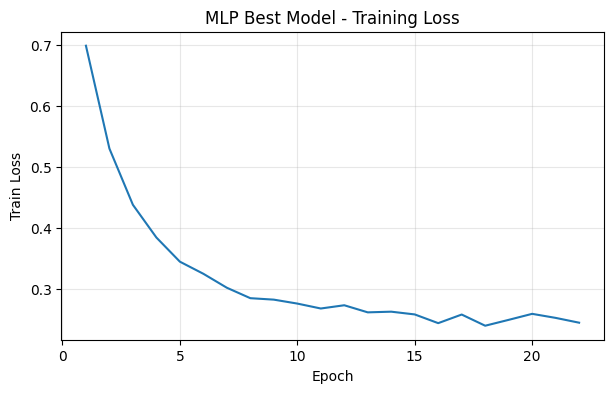

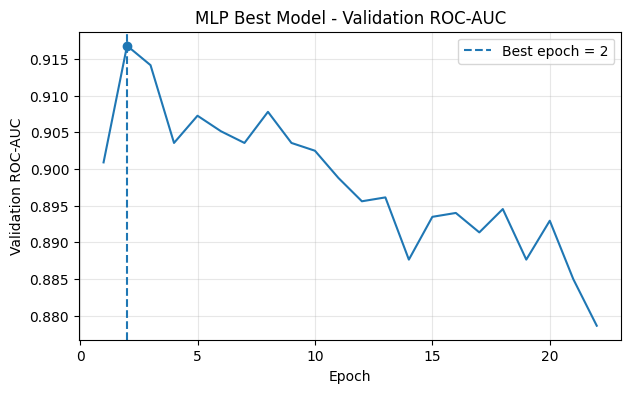

Best epoch: 2
Best Validation ROC-AUC: 0.916799


In [36]:
import matplotlib.pyplot as plt

best_condition = best_stage2_condition

best_history_df = stage2_histories[best_condition].copy()

print("Best condition:", best_condition)
display(best_history_df)

# -----------------------------
# Train loss
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(
    best_history_df["epoch"],
    best_history_df["train_loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MLP Best Model - Training Loss")
plt.grid(alpha=0.3)
plt.show()


# -----------------------------
# Validation ROC-AUC
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(
    best_history_df["epoch"],
    best_history_df["val_roc_auc"]
)

best_epoch = int(
    stage2_results_df.loc[
        stage2_results_df["condition"] == best_condition,
        "best_epoch"
    ].iloc[0]
)

best_auc = float(
    stage2_results_df.loc[
        stage2_results_df["condition"] == best_condition,
        "val_roc_auc"
    ].iloc[0]
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.scatter(
    [best_epoch],
    [best_auc],
    zorder=3
)

plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("MLP Best Model - Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Best epoch: {best_epoch}")
print(f"Best Validation ROC-AUC: {best_auc:.6f}")

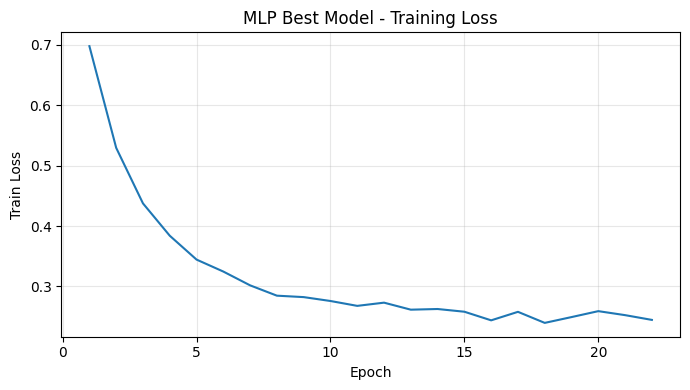

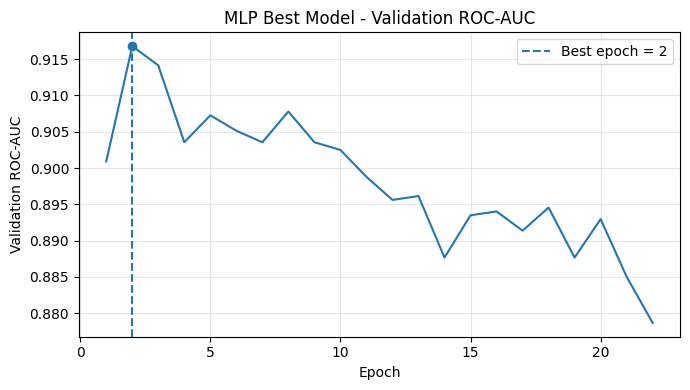

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage2_BestModel_学習履歴.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage2_BestModel_TrainingLoss.png
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Stage2_BestModel_ValidationROC_AUC.png


In [37]:
# =========================================
# MLP Best条件の学習曲線を保存
# =========================================

import os
import matplotlib.pyplot as plt

best_condition = best_stage2_condition
best_history_df = stage2_histories[best_condition].copy()

best_epoch = int(
    stage2_results_df.loc[
        stage2_results_df["condition"] == best_condition,
        "best_epoch"
    ].iloc[0]
)

best_auc = float(
    stage2_results_df.loc[
        stage2_results_df["condition"] == best_condition,
        "val_roc_auc"
    ].iloc[0]
)

# 1. 元データも保存
history_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage2_BestModel_学習履歴.csv"
)

best_history_df.to_csv(
    history_path,
    index=False,
    encoding="utf-8-sig"
)


# 2. Training Loss
loss_fig_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage2_BestModel_TrainingLoss.png"
)

plt.figure(figsize=(7, 4))

plt.plot(
    best_history_df["epoch"],
    best_history_df["train_loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MLP Best Model - Training Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    loss_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 3. Validation ROC-AUC
auc_fig_path = os.path.join(
    MLP_MODEL_DIR,
    "TaskB_MLP_Stage2_BestModel_ValidationROC_AUC.png"
)

plt.figure(figsize=(7, 4))

plt.plot(
    best_history_df["epoch"],
    best_history_df["val_roc_auc"]
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.scatter(
    [best_epoch],
    [best_auc],
    zorder=3
)

plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("MLP Best Model - Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    auc_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("保存完了")
print(history_path)
print(loss_fig_path)
print(auc_fig_path)

In [38]:
# ============================================================
# Task B Clinical MLP
# 過学習確認後の限定再評価：4条件
# ============================================================

refine_results = []
refine_models = {}
refine_val_probs = {}
refine_histories = {}

weight_decays_refine = [
    1e-4,
    1e-3
]

batch_sizes_refine = [
    32,
    64
]

condition_id = 0

for wd in weight_decays_refine:
    for bs in batch_sizes_refine:

        condition_id += 1

        print(
            f"\n[{condition_id}/4] "
            f"hidden=64->32, "
            f"dropout=0.2, "
            f"lr=0.0001, "
            f"weight_decay={wd}, "
            f"batch_size={bs}, "
            f"pos_weight=1.0"
        )

        result, model, val_prob, history_df = train_one_mlp(
            hidden1=64,
            hidden2=32,
            dropout=0.2,
            learning_rate=1e-4,

            weight_decay=wd,
            batch_size=bs,
            pos_weight_value=1.0,

            max_epochs=200,
            patience=20,
            min_delta=1e-4,
            seed=42
        )

        condition_name = (
            f"h64_32"
            f"_drop0.2"
            f"_lr0.0001"
            f"_wd{wd}"
            f"_bs{bs}"
            f"_pw1.0"
        )

        result["condition"] = condition_name

        refine_results.append(result)
        refine_models[condition_name] = copy.deepcopy(model).cpu()
        refine_val_probs[condition_name] = val_prob.copy()
        refine_histories[condition_name] = history_df.copy()

        print(
            f"Val ROC-AUC = {result['val_roc_auc']:.6f} | "
            f"PR-AUC = {result['val_pr_auc']:.6f} | "
            f"Brier = {result['val_brier']:.6f} | "
            f"ECE = {result['val_ece']:.6f} | "
            f"best epoch = {result['best_epoch']}"
        )


# ------------------------------------------------------------
# 結果整理
# ------------------------------------------------------------
refine_results_df = pd.DataFrame(refine_results)

refine_results_df = (
    refine_results_df
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n=== MLP 限定再評価 4条件 ===")

display(
    refine_results_df[
        [
            "condition",
            "weight_decay",
            "batch_size",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)

best_refine_condition = refine_results_df.loc[
    0,
    "condition"
]

print("\n=== 限定再評価 Best ===")
print("condition:", best_refine_condition)

print(
    refine_results_df.iloc[0][
        [
            "weight_decay",
            "batch_size",
            "val_roc_auc",
            "val_pr_auc",
            "val_brier",
            "val_ece",
            "best_epoch",
            "epochs_trained"
        ]
    ]
)


[1/4] hidden=64->32, dropout=0.2, lr=0.0001, weight_decay=0.0001, batch_size=32, pos_weight=1.0
Val ROC-AUC = 0.915209 | PR-AUC = 0.705940 | Brier = 0.118835 | ECE = 0.229673 | best epoch = 24

[2/4] hidden=64->32, dropout=0.2, lr=0.0001, weight_decay=0.0001, batch_size=64, pos_weight=1.0
Val ROC-AUC = 0.918389 | PR-AUC = 0.717544 | Brier = 0.167252 | ECE = 0.304689 | best epoch = 24

[3/4] hidden=64->32, dropout=0.2, lr=0.0001, weight_decay=0.001, batch_size=32, pos_weight=1.0
Val ROC-AUC = 0.915209 | PR-AUC = 0.705940 | Brier = 0.118837 | ECE = 0.229681 | best epoch = 24

[4/4] hidden=64->32, dropout=0.2, lr=0.0001, weight_decay=0.001, batch_size=64, pos_weight=1.0
Val ROC-AUC = 0.918389 | PR-AUC = 0.717544 | Brier = 0.167267 | ECE = 0.304711 | best epoch = 24

=== MLP 限定再評価 4条件 ===


,condition,weight_decay,batch_size,val_roc_auc,val_pr_auc,val_brier,val_ece,best_epoch,epochs_trained
0,h64_32_drop0.2_lr0.0001_wd0.0001_bs64_pw1.0,0.0001,64,0.918389,0.717544,0.167252,0.304689,24,44
1,h64_32_drop0.2_lr0.0001_wd0.001_bs64_pw1.0,0.0010,64,0.918389,0.717544,0.167267,0.304711,24,44
2,h64_32_drop0.2_lr0.0001_wd0.0001_bs32_pw1.0,0.0001,32,0.915209,0.705940,0.118835,0.229673,24,44
3,h64_32_drop0.2_lr0.0001_wd0.001_bs32_pw1.0,0.0010,32,0.915209,0.705940,0.118837,0.229681,24,44



=== 限定再評価 Best ===
condition: h64_32_drop0.2_lr0.0001_wd0.0001_bs64_pw1.0
weight_decay        0.0001
batch_size              64
val_roc_auc       0.918389
val_pr_auc        0.717544
val_brier         0.167252
val_ece           0.304689
best_epoch              24
epochs_trained          44
Name: 0, dtype: object


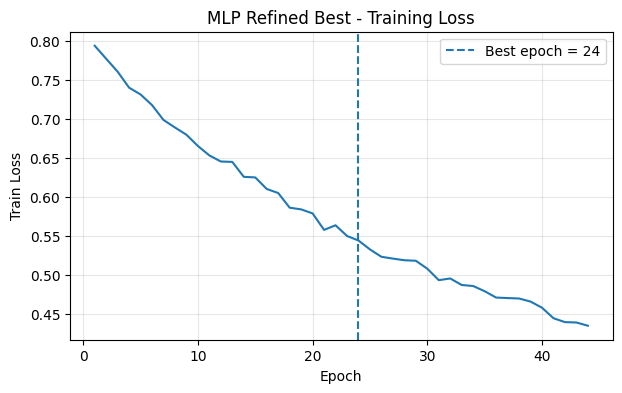

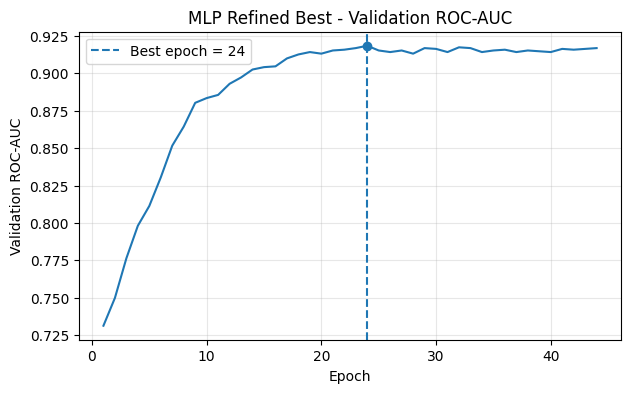

Best epoch: 24
Best Validation ROC-AUC: 0.918389


In [39]:
# =========================================
# 限定再評価Bestの学習曲線確認
# =========================================

import matplotlib.pyplot as plt

best_refine_history_df = refine_histories[
    best_refine_condition
].copy()

best_refine_epoch = int(
    refine_results_df.loc[
        refine_results_df["condition"] == best_refine_condition,
        "best_epoch"
    ].iloc[0]
)

best_refine_auc = float(
    refine_results_df.loc[
        refine_results_df["condition"] == best_refine_condition,
        "val_roc_auc"
    ].iloc[0]
)

# Train loss
plt.figure(figsize=(7, 4))
plt.plot(
    best_refine_history_df["epoch"],
    best_refine_history_df["train_loss"]
)
plt.axvline(
    best_refine_epoch,
    linestyle="--",
    label=f"Best epoch = {best_refine_epoch}"
)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MLP Refined Best - Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Validation ROC-AUC
plt.figure(figsize=(7, 4))
plt.plot(
    best_refine_history_df["epoch"],
    best_refine_history_df["val_roc_auc"]
)
plt.axvline(
    best_refine_epoch,
    linestyle="--",
    label=f"Best epoch = {best_refine_epoch}"
)
plt.scatter(
    [best_refine_epoch],
    [best_refine_auc],
    zorder=3
)
plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("MLP Refined Best - Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Best epoch:", best_refine_epoch)
print(f"Best Validation ROC-AUC: {best_refine_auc:.6f}")

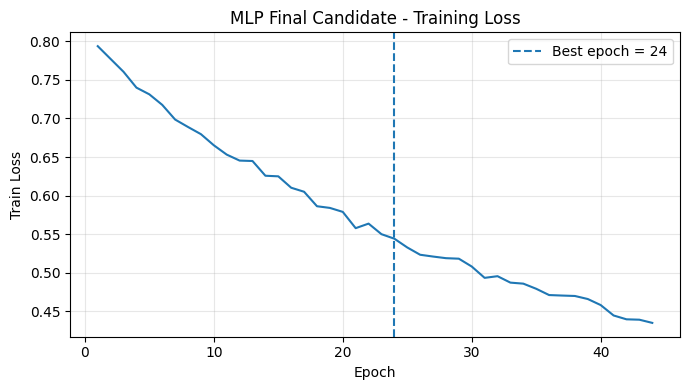

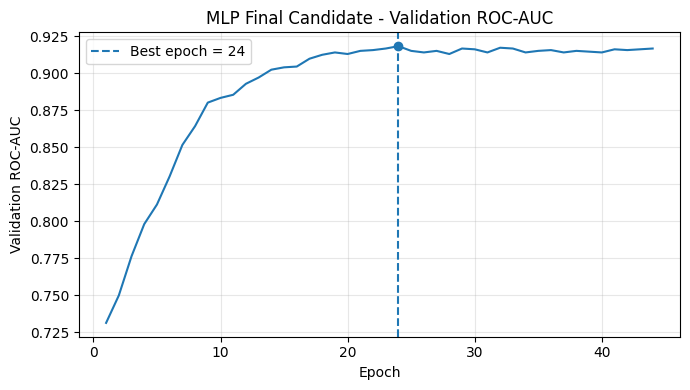

=== 保存完了 ===
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_限定再評価_4条件比較.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_限定再評価_Validation患者別予測確率.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_限定再評価_全条件学習履歴.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_FinalCandidate_学習履歴.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_FinalCandidate_bestmodel.pth
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_FinalCandidate_TrainingLoss.png
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_FinalCandidate_ValidationROC_AUC.png


In [40]:
# ============================================================
# Task B MLP 限定再評価 + 最終候補モデル 保存
# ============================================================

import os
import copy
import torch
import pandas as pd
import matplotlib.pyplot as plt

SAVE_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling"
)

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. 限定再評価4条件 比較表
# ------------------------------------------------------------
refine_results_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_限定再評価_4条件比較.csv"
)

refine_results_df.to_csv(
    refine_results_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 2. Validation 患者別予測確率
# ------------------------------------------------------------
refine_val_prob_df = pd.DataFrame({
    "Subject ID": clinical_df.loc[
        clinical_df["split"] == "val",
        "Subject ID"
    ].to_numpy(),
    "true_label": y_val_np
})

for condition_name, prob in refine_val_probs.items():
    refine_val_prob_df[condition_name] = prob

refine_val_prob_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_限定再評価_Validation患者別予測確率.csv"
)

refine_val_prob_df.to_csv(
    refine_val_prob_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 3. 4条件すべての学習履歴
# ------------------------------------------------------------
refine_history_list = []

for condition_name, hist_df in refine_histories.items():
    tmp = hist_df.copy()
    tmp.insert(0, "condition", condition_name)
    refine_history_list.append(tmp)

refine_history_all_df = pd.concat(
    refine_history_list,
    ignore_index=True
)

refine_history_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_限定再評価_全条件学習履歴.csv"
)

refine_history_all_df.to_csv(
    refine_history_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 4. 最終候補モデルの学習履歴
# ------------------------------------------------------------
final_mlp_condition = best_refine_condition

final_mlp_history_df = refine_histories[
    final_mlp_condition
].copy()

final_history_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_FinalCandidate_学習履歴.csv"
)

final_mlp_history_df.to_csv(
    final_history_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 5. 最終候補モデル checkpoint
# ------------------------------------------------------------
final_mlp_model = copy.deepcopy(
    refine_models[final_mlp_condition]
)

final_checkpoint_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_FinalCandidate_bestmodel.pth"
)

torch.save(
    {
        "model_state_dict": final_mlp_model.state_dict(),

        "input_dim": 12,
        "hidden1": 64,
        "hidden2": 32,
        "dropout": 0.2,

        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "pos_weight": 1.0,

        "optimizer": "AdamW",
        "activation": "ReLU",
        "batch_norm": True,

        "max_epochs": 200,
        "patience": 20,
        "min_delta": 1e-4,

        "best_epoch": 24,
        "val_roc_auc": 0.918389,
        "val_pr_auc": 0.717544,

        "random_seed": 42
    },
    final_checkpoint_path
)


# ------------------------------------------------------------
# 6. Training Loss 図
# ------------------------------------------------------------
train_loss_fig_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_FinalCandidate_TrainingLoss.png"
)

plt.figure(figsize=(7, 4))

plt.plot(
    final_mlp_history_df["epoch"],
    final_mlp_history_df["train_loss"]
)

plt.axvline(
    24,
    linestyle="--",
    label="Best epoch = 24"
)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("MLP Final Candidate - Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    train_loss_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. Validation ROC-AUC 図
# ------------------------------------------------------------
val_auc_fig_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_FinalCandidate_ValidationROC_AUC.png"
)

plt.figure(figsize=(7, 4))

plt.plot(
    final_mlp_history_df["epoch"],
    final_mlp_history_df["val_roc_auc"]
)

plt.axvline(
    24,
    linestyle="--",
    label="Best epoch = 24"
)

plt.scatter(
    [24],
    [0.918389],
    zorder=3
)

plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("MLP Final Candidate - Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    val_auc_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. 保存確認
# ------------------------------------------------------------
print("=== 保存完了 ===")
print(refine_results_path)
print(refine_val_prob_path)
print(refine_history_path)
print(final_history_path)
print(final_checkpoint_path)
print(train_loss_fig_path)
print(val_auc_fig_path)

In [41]:
# ============================================================
# Task B MLP
# Validation Youden Index による閾値決定
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

# 最終候補MLPのValidation予測確率
mlp_val_prob = refine_val_probs[
    best_refine_condition
].copy()

# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_val_np,
    mlp_val_prob
)

# Youden index
youden_index = tpr - fpr

best_idx = np.argmax(youden_index)

MLP_FINAL_THRESHOLD = thresholds[best_idx]

mlp_val_sensitivity = tpr[best_idx]
mlp_val_specificity = 1 - fpr[best_idx]
mlp_val_youden = youden_index[best_idx]

print("=== Task B MLP Validation Youden Threshold ===")
print(f"Threshold   : {MLP_FINAL_THRESHOLD:.9f}")
print(f"Sensitivity : {mlp_val_sensitivity:.6f}")
print(f"Specificity : {mlp_val_specificity:.6f}")
print(f"Youden index: {mlp_val_youden:.6f}")

=== Task B MLP Validation Youden Threshold ===
Threshold   : 0.494784951
Sensitivity : 0.941176
Specificity : 0.837838
Youden index: 0.779014


In [42]:
# ============================================================
# Task B MLP Validation Youden 閾値 保存
# ============================================================

mlp_threshold_df = pd.DataFrame([{
    "model": "TaskB_MLP",
    "threshold_method": "Youden index on Validation set",
    "threshold": MLP_FINAL_THRESHOLD,
    "validation_sensitivity": mlp_val_sensitivity,
    "validation_specificity": mlp_val_specificity,
    "validation_youden_index": mlp_val_youden
}])

mlp_threshold_path = os.path.join(
    SAVE_DIR,
    "TaskB_MLP_Validation_Youden閾値.csv"
)

mlp_threshold_df.to_csv(
    mlp_threshold_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(mlp_threshold_path)
display(mlp_threshold_df)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/04_Modeling/TaskB_MLP_Validation_Youden閾値.csv


,model,threshold_method,threshold,validation_sensitivity,validation_specificity,validation_youden_index
0,TaskB_MLP,Youden index on Validation set,0.494785,0.941176,0.837838,0.779014


In [43]:
# ============================================================
# Task B MLP
# FINAL Test evaluation
# ============================================================

import numpy as np
import torch
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Testデータ準備
# ------------------------------------------------------------
X_test_np = to_numpy(X_test).astype(np.float32)
y_test_np = to_numpy(y_test).reshape(-1).astype(np.float32)

assert X_test_np.shape[1] == 12
assert not np.isnan(X_test_np).any()

X_test_tensor = torch.tensor(
    X_test_np,
    dtype=torch.float32,
    device=device
)

# ------------------------------------------------------------
# 2. 最終MLPモデル
# ------------------------------------------------------------
final_mlp_model = refine_models[
    best_refine_condition
].to(device)

final_mlp_model.eval()

# ------------------------------------------------------------
# 3. Test予測確率
# ------------------------------------------------------------
with torch.no_grad():
    test_logits = final_mlp_model(X_test_tensor)
    mlp_test_prob = torch.sigmoid(
        test_logits
    ).cpu().numpy()

# ------------------------------------------------------------
# 4. 閾値固定
# ------------------------------------------------------------
mlp_test_pred = (
    mlp_test_prob >= MLP_FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# 5. Threshold-free metrics
# ------------------------------------------------------------
mlp_test_roc_auc = roc_auc_score(
    y_test_np,
    mlp_test_prob
)

mlp_test_pr_auc = average_precision_score(
    y_test_np,
    mlp_test_prob
)

mlp_test_brier = brier_score_loss(
    y_test_np,
    mlp_test_prob
)

mlp_test_ece = calculate_ece(
    y_test_np,
    mlp_test_prob,
    n_bins=10
)

# ------------------------------------------------------------
# 6. Confusion matrix
# ------------------------------------------------------------
tn, fp, fn, tp = confusion_matrix(
    y_test_np,
    mlp_test_pred
).ravel()

mlp_test_sensitivity = tp / (tp + fn)
mlp_test_specificity = tn / (tn + fp)

mlp_test_accuracy = accuracy_score(
    y_test_np,
    mlp_test_pred
)

mlp_test_precision = precision_score(
    y_test_np,
    mlp_test_pred,
    zero_division=0
)

# ------------------------------------------------------------
# 7. 結果表示
# ------------------------------------------------------------
print("=== Task B MLP FINAL Test Evaluation ===")

print(f"ROC-AUC    : {mlp_test_roc_auc:.6f}")
print(f"PR-AUC     : {mlp_test_pr_auc:.6f}")
print(f"Brier      : {mlp_test_brier:.6f}")
print(f"ECE        : {mlp_test_ece:.6f}")

print()
print(f"Threshold  : {MLP_FINAL_THRESHOLD:.9f}")
print(f"Sensitivity: {mlp_test_sensitivity:.6f}")
print(f"Specificity: {mlp_test_specificity:.6f}")
print(f"Accuracy   : {mlp_test_accuracy:.6f}")
print(f"Precision  : {mlp_test_precision:.6f}")

print()
print("Confusion matrix")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

=== Task B MLP FINAL Test Evaluation ===
ROC-AUC    : 0.879703
PR-AUC     : 0.688972
Brier      : 0.168616
ECE        : 0.308812

Threshold  : 0.494784951
Sensitivity: 0.764706
Specificity: 0.810811
Accuracy   : 0.804688
Precision  : 0.382353

Confusion matrix
TN=90, FP=21, FN=4, TP=13


In [44]:
# ============================================================
# Task B MLP Test 患者別予測 保存
# ============================================================

mlp_test_patient_df = pd.DataFrame({
    "Subject ID": clinical_df.loc[
        clinical_df["split"] == "test",
        "Subject ID"
    ].to_numpy(),
    "true_label": y_test_np.astype(int),
    "prob": mlp_test_prob,
    "pred": mlp_test_pred
})

mlp_test_patient_path = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_MLP_Test患者別予測.csv"
)

mlp_test_patient_df.to_csv(
    mlp_test_patient_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(mlp_test_patient_path)
print("rows:", len(mlp_test_patient_df))
display(mlp_test_patient_df.head())

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_MLP_Test患者別予測.csv
rows: 128


,Subject ID,true_label,prob,pred
0,A387558,1,0.643152,1
1,A642300,1,0.731202,1
2,A769593,1,0.515946,1
3,A104425,0,0.410286,0
4,A919435,0,0.569114,1


In [45]:
# =========================================
# Task B MLP Test ROC-AUC 95% CI
# stratified bootstrap 10,000回
# =========================================

import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(42)

y_test_np = np.asarray(y_test_np)
mlp_test_prob_np = np.asarray(mlp_test_prob)

pos_idx = np.where(y_test_np == 1)[0]
neg_idx = np.where(y_test_np == 0)[0]

n_boot = 10000
boot_aucs = []

for _ in range(n_boot):
    boot_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )

    boot_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    boot_idx = np.concatenate([
        boot_pos,
        boot_neg
    ])

    auc = roc_auc_score(
        y_test_np[boot_idx],
        mlp_test_prob_np[boot_idx]
    )

    boot_aucs.append(auc)

boot_aucs = np.array(boot_aucs)

mlp_auc_ci_lower = np.percentile(
    boot_aucs,
    2.5
)

mlp_auc_ci_upper = np.percentile(
    boot_aucs,
    97.5
)

print("=== Task B MLP Test ROC-AUC 95% CI ===")
print(f"ROC-AUC : {mlp_test_roc_auc:.6f}")
print(f"95% CI  : {mlp_auc_ci_lower:.4f} - {mlp_auc_ci_upper:.4f}")
print(f"Bootstrap repetitions: {n_boot}")
print("Random seed: 42")

=== Task B MLP Test ROC-AUC 95% CI ===
ROC-AUC : 0.879703
95% CI  : 0.7679 - 0.9624
Bootstrap repetitions: 10000
Random seed: 42


In [46]:
# ============================================================
# Task B MLP 最終Test評価結果 保存
# ============================================================

mlp_final_metrics_df = pd.DataFrame([{
    "model": "TaskB_MLP",

    # 最終モデル条件
    "hidden1": 64,
    "hidden2": 32,
    "dropout": 0.2,
    "learning_rate": 1e-4,
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "batch_size": 64,
    "pos_weight": 1.0,
    "batch_norm": True,
    "activation": "ReLU",
    "best_epoch": 24,

    # Validationで固定した閾値
    "threshold": MLP_FINAL_THRESHOLD,

    # Test評価
    "roc_auc": mlp_test_roc_auc,
    "roc_auc_ci_lower": mlp_auc_ci_lower,
    "roc_auc_ci_upper": mlp_auc_ci_upper,
    "pr_auc": mlp_test_pr_auc,
    "brier_score": mlp_test_brier,
    "ece": mlp_test_ece,
    "sensitivity": mlp_test_sensitivity,
    "specificity": mlp_test_specificity,
    "accuracy": mlp_test_accuracy,
    "precision": mlp_test_precision,

    # 混同行列
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,

    # Bootstrap条件
    "bootstrap_repetitions": 10000,
    "bootstrap_seed": 42
}])

mlp_metrics_path = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_MLP_最終Test評価結果.csv"
)

mlp_final_metrics_df.to_csv(
    mlp_metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(mlp_metrics_path)
display(mlp_final_metrics_df)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_MLP_最終Test評価結果.csv


,model,hidden1,hidden2,dropout,learning_rate,optimizer,weight_decay,batch_size,pos_weight,batch_norm,...,sensitivity,specificity,accuracy,precision,TN,FP,FN,TP,bootstrap_repetitions,bootstrap_seed
0,TaskB_MLP,64,32,0.2,0.0001,AdamW,0.0001,64,1.0,True,...,0.764706,0.810811,0.804688,0.382353,90,21,4,13,10000,42


In [49]:
for name, obj in list(globals().items()):
    if hasattr(obj, "predict_proba"):
        print(name, type(obj))

LogisticRegression <class 'type'>
best_model <class 'sklearn.linear_model._logistic.LogisticRegression'>
best_xgb_model <class 'xgboost.sklearn.XGBClassifier'>


In [50]:
# ============================================================
# Task B
# LR / XGBoost / MLP 共通 Permutation Importance
# Validation ROC-AUC decrease
# ============================================================

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. 共通設定
# ------------------------------------------------------------
N_REPEATS = 30
RANDOM_SEED = 42

print("Permutation repeats:", N_REPEATS)
print("Random seed:", RANDOM_SEED)


# ------------------------------------------------------------
# 2. 各モデルの予測関数
# ------------------------------------------------------------

# Logistic Regression
def predict_lr(X):
    return best_model.predict_proba(X)[:, 1]


# XGBoost
def predict_xgb(X):

    # XGBoostでは [ ] < を含むfeature名が使えないため、
    # 学習時と同じ名前に変更
    X_tmp = X.copy()

    X_tmp = X_tmp.rename(columns={
        "age_(59,74]": "age_59_74",
        "age_(74,90]": "age_74_90"
    })

    return best_xgb_model.predict_proba(X_tmp)[:, 1]


# MLP
def predict_mlp(X):

    X_np = X.to_numpy().astype(np.float32)

    X_tensor = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device
    )

    final_mlp_model.eval()

    with torch.no_grad():

        logits = final_mlp_model(X_tensor)

        prob = torch.sigmoid(
            logits
        ).cpu().numpy()

    return prob


# ------------------------------------------------------------
# 3. Permutation Importance関数
#
# 各特徴量を1列ずつシャッフル
# baseline AUC - permutation後AUC
# が大きいほど、その特徴量への依存が強い
# ------------------------------------------------------------

def permutation_importance_auc(
    model_name,
    predict_func,
    X,
    y,
    n_repeats=30,
    seed=42
):

    X = X.copy()
    y = np.asarray(y).reshape(-1)

    # Baseline Validation ROC-AUC
    baseline_prob = predict_func(X)

    baseline_auc = roc_auc_score(
        y,
        baseline_prob
    )

    print(
        f"\n{model_name} baseline Validation ROC-AUC: "
        f"{baseline_auc:.6f}"
    )

    results = []

    # 特徴量ごとに独立したseedを使えるようにする
    base_rng = np.random.default_rng(seed)

    for feature in X.columns:

        decreases = []

        for _ in range(n_repeats):

            X_perm = X.copy()

            # 現在の列だけシャッフル
            shuffled_values = (
                X_perm[feature]
                .to_numpy()
                .copy()
            )

            base_rng.shuffle(
                shuffled_values
            )

            X_perm[feature] = shuffled_values

            perm_prob = predict_func(
                X_perm
            )

            perm_auc = roc_auc_score(
                y,
                perm_prob
            )

            auc_decrease = (
                baseline_auc
                - perm_auc
            )

            decreases.append(
                auc_decrease
            )

        decreases = np.asarray(
            decreases
        )

        results.append({
            "model": model_name,
            "feature": feature,
            "baseline_val_auc": baseline_auc,

            "importance_mean_auc_decrease":
                decreases.mean(),

            "importance_sd":
                decreases.std(ddof=1),

            "importance_median":
                np.median(decreases),

            "importance_min":
                decreases.min(),

            "importance_max":
                decreases.max(),

            "n_repeats": n_repeats
        })

    result_df = pd.DataFrame(
        results
    )

    result_df = (
        result_df
        .sort_values(
            "importance_mean_auc_decrease",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return result_df


# ------------------------------------------------------------
# 4. Logistic Regression
# ------------------------------------------------------------

lr_perm_df = permutation_importance_auc(
    model_name="Logistic Regression",
    predict_func=predict_lr,
    X=X_val,
    y=y_val_np,
    n_repeats=N_REPEATS,
    seed=RANDOM_SEED
)

print("\n=== Logistic Regression Permutation Importance ===")

display(
    lr_perm_df
)


# ------------------------------------------------------------
# 5. XGBoost
# ------------------------------------------------------------

xgb_perm_df = permutation_importance_auc(
    model_name="XGBoost",
    predict_func=predict_xgb,
    X=X_val,
    y=y_val_np,
    n_repeats=N_REPEATS,
    seed=RANDOM_SEED
)

print("\n=== XGBoost Permutation Importance ===")

display(
    xgb_perm_df
)


# ------------------------------------------------------------
# 6. MLP
# ------------------------------------------------------------

mlp_perm_df = permutation_importance_auc(
    model_name="MLP",
    predict_func=predict_mlp,
    X=X_val,
    y=y_val_np,
    n_repeats=N_REPEATS,
    seed=RANDOM_SEED
)

print("\n=== MLP Permutation Importance ===")

display(
    mlp_perm_df
)


# ------------------------------------------------------------
# 7. 3モデルを結合
# ------------------------------------------------------------

all_perm_df = pd.concat(
    [
        lr_perm_df,
        xgb_perm_df,
        mlp_perm_df
    ],
    ignore_index=True
)

print("\n=== All Models Permutation Importance ===")

display(
    all_perm_df
)


# ------------------------------------------------------------
# 8. 各モデル上位5特徴を確認
# ------------------------------------------------------------

print("\n=== Top 5 Features ===")

for model_name in [
    "Logistic Regression",
    "XGBoost",
    "MLP"
]:

    print(f"\n--- {model_name} ---")

    display(
        all_perm_df[
            all_perm_df["model"]
            == model_name
        ][
            [
                "feature",
                "importance_mean_auc_decrease",
                "importance_sd"
            ]
        ].head(5)
    )

Permutation repeats: 30
Random seed: 42

Logistic Regression baseline Validation ROC-AUC: 0.896131

=== Logistic Regression Permutation Importance ===


,model,feature,baseline_val_auc,importance_mean_auc_decrease,importance_sd,importance_median,importance_min,importance_max,n_repeats
0,Logistic Regression,lactate,0.896131,0.088659,0.020903,0.088235,0.043455,0.124536,30
1,Logistic Regression,spo2,0.896131,0.070588,0.015053,0.069157,0.043985,0.098569,30
2,Logistic Regression,"age_(74,90]",0.896131,0.055379,0.020202,0.054849,0.003180,0.090620,30
3,Logistic Regression,crp,0.896131,0.018336,0.013186,0.014308,-0.005299,0.046635,30
4,Logistic Regression,egfr,0.896131,0.012666,0.011748,0.012719,-0.011129,0.033386,30
5,Logistic Regression,ddimer,0.896131,0.005865,0.006739,0.005829,-0.014308,0.016428,30
6,Logistic Regression,hf_HFpEF,0.896131,0.004858,0.003403,0.005034,-0.004769,0.010599,30
7,Logistic Regression,sex_MALE,0.896131,0.002826,0.007054,0.003180,-0.016958,0.018018,30
8,Logistic Regression,lymph,0.896131,0.001078,0.016695,-0.000795,-0.023317,0.043985,30
9,Logistic Regression,hf_Missing,0.896131,-0.002632,0.001193,-0.003180,-0.004240,-0.000530,30



XGBoost baseline Validation ROC-AUC: 0.885533

=== XGBoost Permutation Importance ===


,model,feature,baseline_val_auc,importance_mean_auc_decrease,importance_sd,importance_median,importance_min,importance_max,n_repeats
0,XGBoost,lactate,0.885533,0.095213,0.026641,0.097112,3.736089e-02,0.162162,30
1,XGBoost,spo2,0.885533,0.074095,0.013078,0.073132,5.325914e-02,0.099099,30
2,XGBoost,"age_(74,90]",0.885533,0.032097,0.013689,0.033916,1.139375e-02,0.060678,30
3,XGBoost,egfr,0.885533,0.028882,0.021069,0.031532,-2.252252e-02,0.060678,30
4,XGBoost,crp,0.885533,0.013231,0.011499,0.012586,-3.974563e-03,0.030472,30
5,XGBoost,lymph,0.885533,0.008099,0.009671,0.008612,-1.801802e-02,0.023052,30
6,XGBoost,sex_MALE,0.885533,0.004328,0.005937,0.002782,-3.179650e-03,0.015898,30
7,XGBoost,ddimer,0.885533,0.003171,0.013400,0.002385,-2.437732e-02,0.036831,30
8,XGBoost,hf_HFpEF,0.885533,0.002738,0.001163,0.002650,1.110223e-16,0.005299,30
9,XGBoost,hf_HFrEF,0.885533,-0.000088,0.001855,0.000530,-6.624271e-03,0.001590,30



MLP baseline Validation ROC-AUC: 0.918389

=== MLP Permutation Importance ===


...

,feature,importance_mean_auc_decrease,importance_sd
0,lactate,0.088659,0.020903
1,spo2,0.070588,0.015053
2,"age_(74,90]",0.055379,0.020202
3,crp,0.018336,0.013186
4,egfr,0.012666,0.011748



--- XGBoost ---


,feature,importance_mean_auc_decrease,importance_sd
12,lactate,0.095213,0.026641
13,spo2,0.074095,0.013078
14,"age_(74,90]",0.032097,0.013689
15,egfr,0.028882,0.021069
16,crp,0.013231,0.011499



--- MLP ---


,feature,importance_mean_auc_decrease,importance_sd
24,spo2,0.120579,0.025254
25,lactate,0.106501,0.029348
26,egfr,0.034075,0.021814
27,crp,0.018689,0.014760
28,"age_(74,90]",0.014891,0.009424


In [51]:
# ============================================================
# Task B 3モデル共通 Permutation Importance 保存
# ============================================================

perm_path = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_3モデル_PermutationImportance_Validation.csv"
)

all_perm_df.to_csv(
    perm_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(perm_path)

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_PermutationImportance_Validation.csv


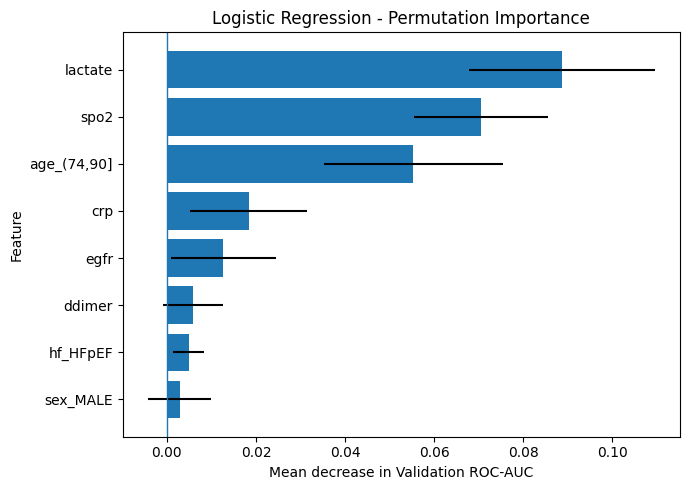

保存: /content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_Logistic_Regression_PermutationImportance_Top8.png


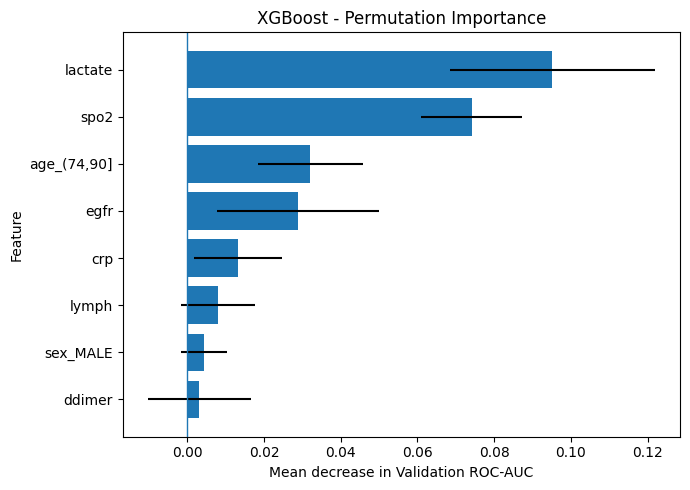

保存: /content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_XGBoost_PermutationImportance_Top8.png


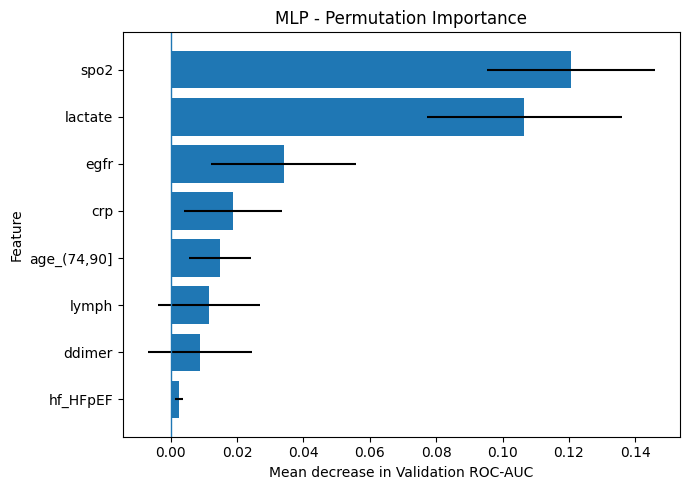

保存: /content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_MLP_PermutationImportance_Top8.png


In [52]:
# ============================================================
# Task B
# LR / XGBoost / MLP Feature Importance 可視化
# Permutation Importance (Validation ROC-AUC decrease)
# ============================================================

import os
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

os.makedirs(FIG_DIR, exist_ok=True)

TOP_N = 8

model_names = [
    "Logistic Regression",
    "XGBoost",
    "MLP"
]

for model_name in model_names:

    plot_df = (
        all_perm_df[
            all_perm_df["model"] == model_name
        ]
        .sort_values(
            "importance_mean_auc_decrease",
            ascending=False
        )
        .head(TOP_N)
        .sort_values(
            "importance_mean_auc_decrease",
            ascending=True
        )
    )

    plt.figure(figsize=(7, 5))

    plt.barh(
        plot_df["feature"],
        plot_df["importance_mean_auc_decrease"],
        xerr=plot_df["importance_sd"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "Mean decrease in Validation ROC-AUC"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"{model_name} - Permutation Importance"
    )

    plt.tight_layout()

    safe_name = (
        model_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    fig_path = os.path.join(
        FIG_DIR,
        f"TaskB_{safe_name}_PermutationImportance_Top{TOP_N}.png"
    )

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("保存:", fig_path)

In [53]:
# ============================================================
# Task B
# LR / XGBoost / MLP 最終Test評価 比較表
# ============================================================

import os
import pandas as pd

EVAL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

# ------------------------------------------------------------
# 1. 各モデルの最終評価CSVを読み込み
# ------------------------------------------------------------
lr_path = os.path.join(
    EVAL_DIR,
    "TaskB_LR_最終Test評価結果.csv"
)

xgb_path = os.path.join(
    EVAL_DIR,
    "TaskB_XGBoost_最終Test評価結果.csv"
)

mlp_path = os.path.join(
    EVAL_DIR,
    "TaskB_MLP_最終Test評価結果.csv"
)

lr_metrics = pd.read_csv(lr_path)
xgb_metrics = pd.read_csv(xgb_path)
mlp_metrics = pd.read_csv(mlp_path)

print("LR :", lr_metrics.shape)
print("XGB:", xgb_metrics.shape)
print("MLP:", mlp_metrics.shape)


# ------------------------------------------------------------
# 2. 共通して比較したい指標だけ抽出
# ------------------------------------------------------------
comparison_columns = [
    "model",
    "roc_auc",
    "roc_auc_ci_lower",
    "roc_auc_ci_upper",
    "pr_auc",
    "brier_score",
    "ece",
    "threshold",
    "sensitivity",
    "specificity",
    "accuracy",
    "precision",
    "TN",
    "FP",
    "FN",
    "TP"
]

comparison_df = pd.concat(
    [
        lr_metrics[comparison_columns],
        xgb_metrics[comparison_columns],
        mlp_metrics[comparison_columns]
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 3. 表示用に95% CI列を追加
# ------------------------------------------------------------
comparison_df["roc_auc_95ci"] = comparison_df.apply(
    lambda row:
        f"{row['roc_auc']:.3f} "
        f"({row['roc_auc_ci_lower']:.3f}–"
        f"{row['roc_auc_ci_upper']:.3f})",
    axis=1
)


# ------------------------------------------------------------
# 4. 見やすい比較表
# ------------------------------------------------------------
display_columns = [
    "model",
    "roc_auc_95ci",
    "pr_auc",
    "brier_score",
    "ece",
    "threshold",
    "sensitivity",
    "specificity",
    "accuracy",
    "precision"
]

taskb_model_comparison_df = comparison_df[
    display_columns
].copy()

print("=== Task B Final Test Model Comparison ===")
display(taskb_model_comparison_df)


# ------------------------------------------------------------
# 5. 詳細版CSVを保存
# ------------------------------------------------------------
comparison_path = os.path.join(
    EVAL_DIR,
    "TaskB_3モデル_最終Test評価比較.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig"
)

print("保存完了")
print(comparison_path)

LR : (1, 20)
XGB: (1, 27)
MLP: (1, 29)
=== Task B Final Test Model Comparison ===


,model,roc_auc_95ci,pr_auc,brier_score,ece,threshold,sensitivity,specificity,accuracy,precision
0,TaskB_LogisticRegression,0.941 (0.888–0.983),0.800251,0.057177,0.041302,0.128797,0.823529,0.810811,0.812500,0.400000
1,TaskB_XGBoost,0.936 (0.877–0.980),0.718188,0.067800,0.090264,0.131138,0.941176,0.783784,0.804688,0.400000
2,TaskB_MLP,0.880 (0.768–0.962),0.688972,0.168616,0.308812,0.494785,0.764706,0.810811,0.804688,0.382353


保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_最終Test評価比較.csv


In [54]:
import os

xgb_patient_path = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_XGBoost_Test患者別予測.csv"
)

print("exists:", os.path.exists(xgb_patient_path))
print(xgb_patient_path)

exists: True
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_XGBoost_Test患者別予測.csv


In [55]:
# ============================================================
# Task B
# LR / XGBoost / MLP Test ROC・PR曲線用データ 保存
# ============================================================

import os
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve

EVAL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

# ------------------------------------------------------------
# 患者別予測CSVを読み込み
# ------------------------------------------------------------
lr_pred = pd.read_csv(
    os.path.join(
        EVAL_DIR,
        "TaskB_LR_Test患者別予測.csv"
    )
)

xgb_pred = pd.read_csv(
    os.path.join(
        EVAL_DIR,
        "TaskB_XGBoost_Test患者別予測.csv"
    )
)

mlp_pred = pd.read_csv(
    os.path.join(
        EVAL_DIR,
        "TaskB_MLP_Test患者別予測.csv"
    )
)

# ------------------------------------------------------------
# Subject ID / true_label の一致確認
# ------------------------------------------------------------
assert lr_pred["Subject ID"].equals(xgb_pred["Subject ID"])
assert lr_pred["Subject ID"].equals(mlp_pred["Subject ID"])

assert lr_pred["true_label"].equals(xgb_pred["true_label"])
assert lr_pred["true_label"].equals(mlp_pred["true_label"])

print("患者ID・true_label一致確認: OK")


# ------------------------------------------------------------
# ROC / PR curve データ作成
# ------------------------------------------------------------
roc_list = []
pr_list = []

for model_name, df in [
    ("Logistic Regression", lr_pred),
    ("XGBoost", xgb_pred),
    ("MLP", mlp_pred)
]:

    y_true = df["true_label"].to_numpy()
    y_prob = df["prob"].to_numpy()

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(
        y_true,
        y_prob
    )

    roc_tmp = pd.DataFrame({
        "model": model_name,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": roc_thresholds
    })

    roc_list.append(roc_tmp)

    # PR
    precision, recall, pr_thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    # thresholdはprecision/recallより1つ短いのでNaNを補う
    pr_threshold_full = list(pr_thresholds) + [float("nan")]

    pr_tmp = pd.DataFrame({
        "model": model_name,
        "recall": recall,
        "precision": precision,
        "threshold": pr_threshold_full
    })

    pr_list.append(pr_tmp)


# ------------------------------------------------------------
# 結合
# ------------------------------------------------------------
taskb_roc_curve_df = pd.concat(
    roc_list,
    ignore_index=True
)

taskb_pr_curve_df = pd.concat(
    pr_list,
    ignore_index=True
)


# ------------------------------------------------------------
# 保存
# ------------------------------------------------------------
roc_path = os.path.join(
    EVAL_DIR,
    "TaskB_3モデル_Test_ROC曲線データ.csv"
)

pr_path = os.path.join(
    EVAL_DIR,
    "TaskB_3モデル_Test_PR曲線データ.csv"
)

taskb_roc_curve_df.to_csv(
    roc_path,
    index=False,
    encoding="utf-8-sig"
)

taskb_pr_curve_df.to_csv(
    pr_path,
    index=False,
    encoding="utf-8-sig"
)

print("=== 保存完了 ===")
print(roc_path)
print(pr_path)
print()
print("ROC rows:", len(taskb_roc_curve_df))
print("PR rows :", len(taskb_pr_curve_df))

患者ID・true_label一致確認: OK
=== 保存完了 ===
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_Test_ROC曲線データ.csv
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_Test_PR曲線データ.csv

ROC rows: 78
PR rows : 348


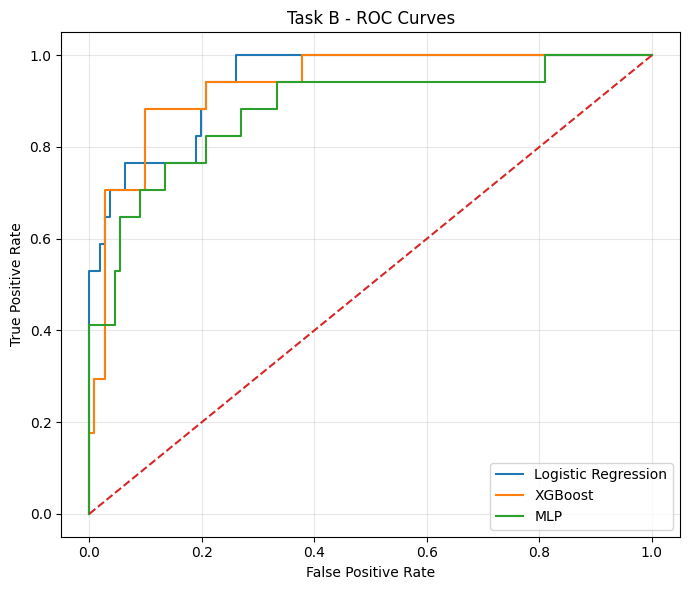

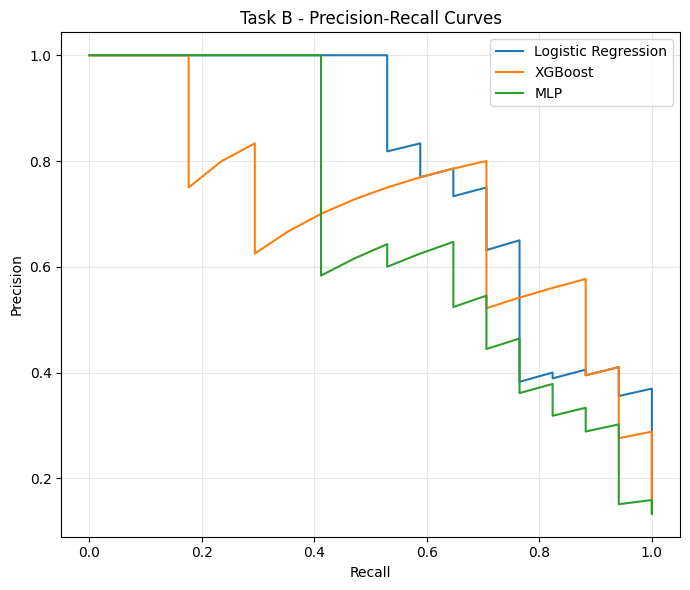

保存完了
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_Test_ROC曲線.png
/content/drive/MyDrive/気合のCOVID19/02_TaskB_臨床データ/05_Evaluation/TaskB_3モデル_Test_PR曲線.png


In [56]:
# ============================================================
# Task B
# 3モデル ROC / PR curve 可視化・保存
# ============================================================

import matplotlib.pyplot as plt
import os

EVAL_DIR = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation"
)

# -----------------------------
# ROC curve
# -----------------------------
plt.figure(figsize=(7, 6))

for model_name in taskb_roc_curve_df["model"].unique():
    tmp = taskb_roc_curve_df[
        taskb_roc_curve_df["model"] == model_name
    ]

    plt.plot(
        tmp["fpr"],
        tmp["tpr"],
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task B - ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

roc_fig_path = os.path.join(
    EVAL_DIR,
    "TaskB_3モデル_Test_ROC曲線.png"
)

plt.savefig(
    roc_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# PR curve
# -----------------------------
plt.figure(figsize=(7, 6))

for model_name in taskb_pr_curve_df["model"].unique():
    tmp = taskb_pr_curve_df[
        taskb_pr_curve_df["model"] == model_name
    ]

    plt.plot(
        tmp["recall"],
        tmp["precision"],
        label=model_name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Task B - Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

pr_fig_path = os.path.join(
    EVAL_DIR,
    "TaskB_3モデル_Test_PR曲線.png"
)

plt.savefig(
    pr_fig_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("保存完了")
print(roc_fig_path)
print(pr_fig_path)